# EKG Classification — CNN + Transformer

Pipeline: **Load Dataset → EDA (Visualisasi) → Preprocessing → Augmentasi**

Dataset: citra EKG hasil scan/foto, disimpan di `dataset/` dengan 4 folder:
- `Abnormal Training`, `Abnormal Testing`
- `Normal Training`, `Normal Testing`

Tahap saat ini: load data, analisis visual, dan preprocessing (grayscale → CLAHE → resize 224×224 → normalisasi) + augmentasi conservative dengan strategi class-specific (Abnormal 1.5× lebih agresif karena minoritas).

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("OpenCV version :", cv2.__version__)
print("Torch version  :", torch.__version__)
print("Device         :", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

OpenCV version : 5.0.0
Torch version  : 2.12.1+cu126
Device         : cuda - NVIDIA GeForce GTX 1080


## 1. Load Dataset

Memindai 4 folder dataset, memetakan setiap file gambar ke `label` (Normal/Abnormal) dan `split` (train/test), lalu memvalidasi bahwa setiap file benar-benar bisa dibuka sebagai citra.

In [2]:
DATASET_DIR = Path("dataset")
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

# folder name -> (label, split)
FOLDER_MAP = {
    "Abnormal Training": ("Abnormal", "train"),
    "Abnormal Testing":  ("Abnormal", "test"),
    "Normal Training":   ("Normal",  "train"),
    "Normal Testing":    ("Normal",  "test"),
}

def scan_dataset(dataset_dir: Path) -> pd.DataFrame:
    records = []
    for folder_name, (label, split) in FOLDER_MAP.items():
        folder_path = dataset_dir / folder_name
        if not folder_path.exists():
            raise FileNotFoundError(f"Folder tidak ditemukan: {folder_path}")
        for f in sorted(folder_path.iterdir()):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS:
                records.append({"filepath": str(f), "label": label, "split": split})
    return pd.DataFrame(records)

def validate_images(df: pd.DataFrame) -> pd.DataFrame:
    """Buang / laporkan file yang gagal dibaca sebagai gambar."""
    valid_mask = []
    for fp in tqdm(df["filepath"], desc="Validating images"):
        img = cv2.imread(fp, cv2.IMREAD_COLOR)
        valid_mask.append(img is not None)
    df = df.copy()
    df["is_valid"] = valid_mask
    n_invalid = (~df["is_valid"]).sum()
    if n_invalid:
        print(f"WARNING: {n_invalid} file gagal dibaca dan akan dibuang:")
        print(df.loc[~df["is_valid"], "filepath"].tolist())
    return df[df["is_valid"]].drop(columns="is_valid").reset_index(drop=True)

df = scan_dataset(DATASET_DIR)
df = validate_images(df)
df.head()

Validating images:   0%|          | 0/580 [00:00<?, ?it/s]

Validating images:   1%|          | 5/580 [00:00<00:12, 45.76it/s]

Validating images:   3%|▎         | 15/580 [00:00<00:07, 76.08it/s]

Validating images:   6%|▌         | 33/580 [00:00<00:04, 119.16it/s]

Validating images:   8%|▊         | 49/580 [00:00<00:03, 133.64it/s]

...

Validating images:  95%|█████████▌| 553/580 [00:04<00:00, 96.96it/s] 

Validating images:  97%|█████████▋| 564/580 [00:04<00:00, 100.29it/s]

Validating images:  99%|█████████▉| 576/580 [00:05<00:00, 104.28it/s]

Validating images: 100%|██████████| 580/580 [00:05<00:00, 113.50it/s]

,filepath,label,split
0,dataset\Abnormal Training\12_1.jpg,Abnormal,train
1,dataset\Abnormal Training\12_2.jpg,Abnormal,train
2,dataset\Abnormal Training\2_1.jpg,Abnormal,train
3,dataset\Abnormal Training\2_2.jpg,Abnormal,train
4,dataset\Abnormal Training\5_1.jpg,Abnormal,train


In [3]:
summary = df.groupby(["split", "label"]).size().unstack(fill_value=0)
print("Ringkasan jumlah data per split & label:")
print(summary)
print("\nTotal data:", len(df))

Ringkasan jumlah data per split & label:
label  Abnormal  Normal
split                  
test         48     291
train       156      85

Total data: 580


## 2. Analisis & Visualisasi Data (EDA)

Mengecek distribusi kelas, contoh citra mentah, distribusi ukuran gambar, dan distribusi intensitas piksel.

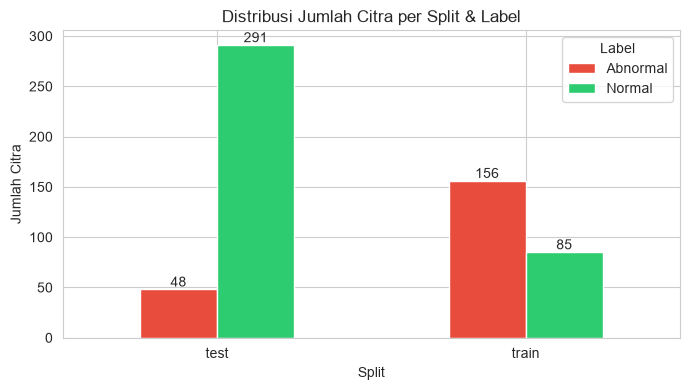

Total per label (train+test):
label
Normal      376
Abnormal    204
Name: count, dtype: int64

Rasio Abnormal:Normal = 204:376 (35.2% : 64.8%)


In [4]:
# --- Distribusi kelas per split ---
fig, ax = plt.subplots(figsize=(7, 4))
summary.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
ax.set_title("Distribusi Jumlah Citra per Split & Label")
ax.set_xlabel("Split")
ax.set_ylabel("Jumlah Citra")
ax.legend(title="Label")
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

label_counts = df["label"].value_counts()
print("Total per label (train+test):")
print(label_counts)
print(f"\nRasio Abnormal:Normal = {label_counts['Abnormal']}:{label_counts['Normal']}"
      f" ({label_counts['Abnormal']/len(df)*100:.1f}% : {label_counts['Normal']/len(df)*100:.1f}%)")

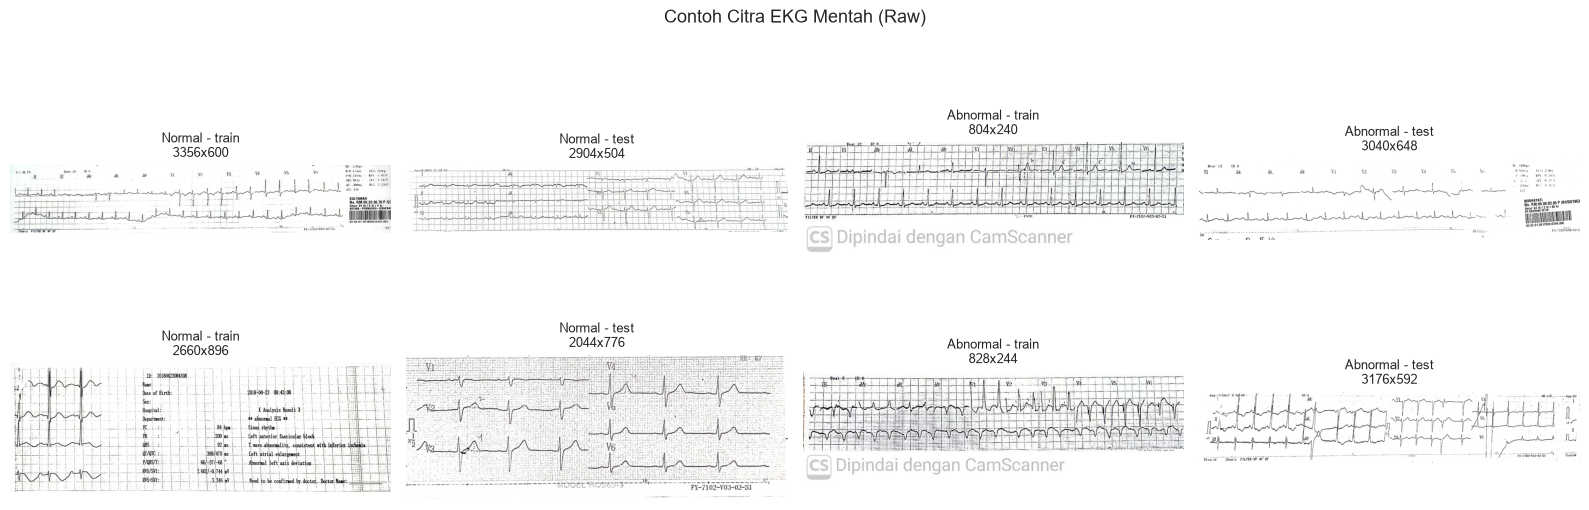

In [5]:
# --- Contoh citra mentah (raw) per kombinasi split/label ---
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
combos = [("Normal", "train"), ("Normal", "test"), ("Abnormal", "train"), ("Abnormal", "test")]

for col, (label, split) in enumerate(combos):
    subset = df[(df["label"] == label) & (df["split"] == split)]
    samples = subset.sample(min(2, len(subset)), random_state=SEED)
    for row, (_, r) in enumerate(samples.iterrows()):
        img = cv2.cvtColor(cv2.imread(r["filepath"]), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{label} - {split}\n{img.shape[1]}x{img.shape[0]}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Contoh Citra EKG Mentah (Raw)", fontsize=13)
plt.tight_layout()
plt.show()

Reading dimensions:   0%|          | 0/580 [00:00<?, ?it/s]

Reading dimensions:  39%|███▉      | 227/580 [00:00<00:00, 2267.65it/s]

Reading dimensions:  81%|████████  | 471/580 [00:00<00:00, 2365.34it/s]

Reading dimensions: 100%|██████████| 580/580 [00:00<00:00, 2361.90it/s]

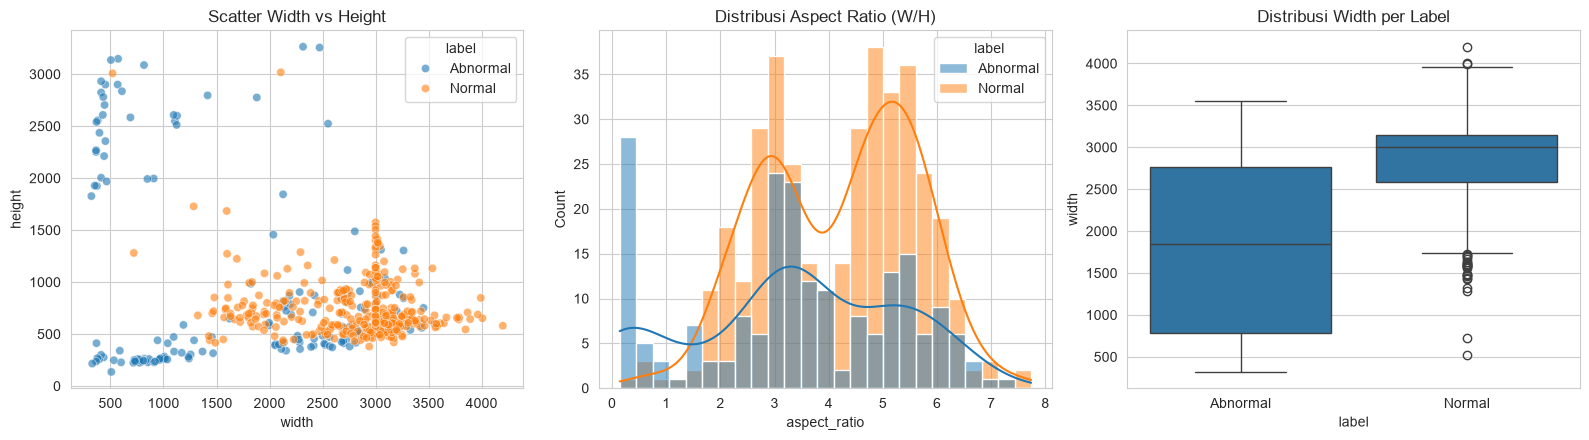

             width       height  aspect_ratio
count   580.000000   580.000000    580.000000
mean   2438.179310   778.844828      3.913856
std     914.218508   547.857920      1.652190
min     320.000000   136.000000      0.140518
25%    1948.000000   524.000000      2.894057
50%    2794.000000   630.000000      3.914981
75%    3088.000000   837.000000      5.263962
max    4200.000000  3264.000000      7.736842


In [6]:
# --- Distribusi ukuran gambar (width, height, aspect ratio) ---
from PIL import Image

dims = []
for _, r in tqdm(df.iterrows(), total=len(df), desc="Reading dimensions"):
    with Image.open(r["filepath"]) as im:
        w, h = im.size
    dims.append({"label": r["label"], "split": r["split"], "width": w, "height": h, "aspect_ratio": w / h})
dims_df = pd.DataFrame(dims)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.scatterplot(data=dims_df, x="width", y="height", hue="label", alpha=0.6, ax=axes[0])
axes[0].set_title("Scatter Width vs Height")

sns.histplot(data=dims_df, x="aspect_ratio", hue="label", kde=True, ax=axes[1], bins=25)
axes[1].set_title("Distribusi Aspect Ratio (W/H)")

sns.boxplot(data=dims_df, x="label", y="width", ax=axes[2])
axes[2].set_title("Distribusi Width per Label")

plt.tight_layout()
plt.show()

print(dims_df[["width", "height", "aspect_ratio"]].describe())

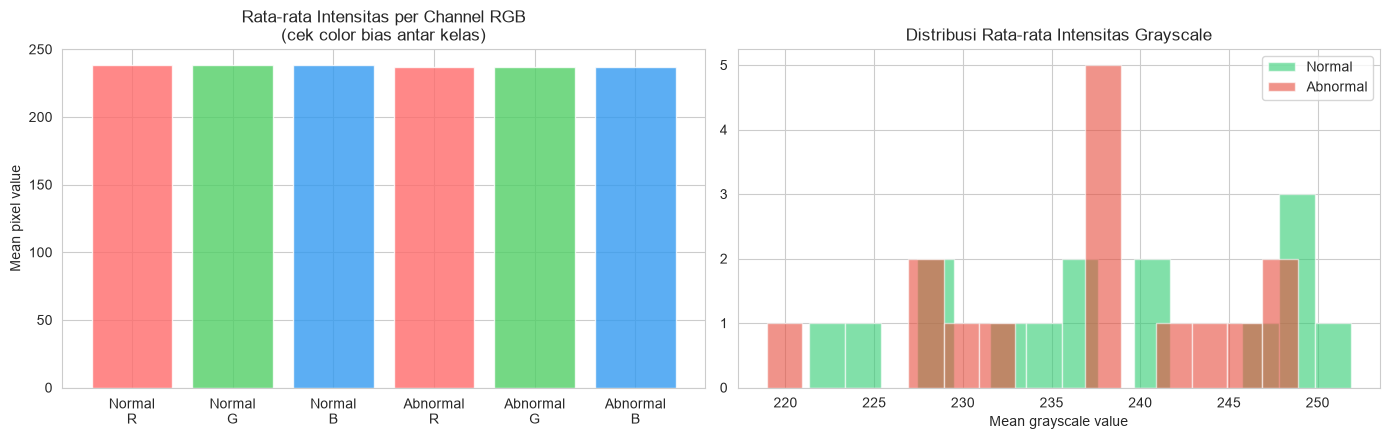

Catatan: jika mean R/G/B berbeda signifikan antar kelas, CNN bisa 'menyontek'
lewat warna alih-alih bentuk gelombang EKG -> alasan kita paksa grayscale (langkah preprocessing b).


In [7]:
# --- Distribusi intensitas piksel per channel RGB (cek color bias, ref. D-14) & grayscale ---
sample_df = pd.concat(
    [grp.sample(min(15, len(grp)), random_state=SEED) for _, grp in df.groupby("label")],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = {"Normal": "#2ecc71", "Abnormal": "#e74c3c"}

for label in ["Normal", "Abnormal"]:
    subset = sample_df[sample_df["label"] == label]
    r_vals, g_vals, b_vals, gray_vals = [], [], [], []
    for fp in subset["filepath"]:
        img_bgr = cv2.imread(fp)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        r_vals.append(img_rgb[:, :, 0].mean())
        g_vals.append(img_rgb[:, :, 1].mean())
        b_vals.append(img_rgb[:, :, 2].mean())
        gray_vals.append(gray.mean())
    axes[0].bar([f"{label}\nR", f"{label}\nG", f"{label}\nB"],
                [np.mean(r_vals), np.mean(g_vals), np.mean(b_vals)],
                color=["#ff6b6b", "#51cf66", "#339af0"], alpha=0.8)
    axes[1].hist(gray_vals, bins=15, alpha=0.6, label=label, color=colors[label])

axes[0].set_title("Rata-rata Intensitas per Channel RGB\n(cek color bias antar kelas)")
axes[0].set_ylabel("Mean pixel value")
axes[1].set_title("Distribusi Rata-rata Intensitas Grayscale")
axes[1].set_xlabel("Mean grayscale value")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Catatan: jika mean R/G/B berbeda signifikan antar kelas, CNN bisa 'menyontek'")
print("lewat warna alih-alih bentuk gelombang EKG -> alasan kita paksa grayscale (langkah preprocessing b).")

## 3. Preprocessing Pipeline

Urutan sesuai spesifikasi:

a. **Load Image** — baca file & validasi
b. **Grayscale Conversion** — RGB → 1 channel (menghilangkan color bias, D-14)
c. **CLAHE** — clip limit 2.0, grid 8×8 (memperjelas gelombang EKG & mengurangi pengaruh grid latar belakang, D-13/D-15)
d. **Resize** — 224×224, interpolasi `INTER_AREA` (cocok untuk downscaling)
e. **Normalization** — ke rentang [0, 1], `float32`

In [8]:
TARGET_SIZE = (224, 224)   # (width, height)
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID = (8, 8)


def load_image(filepath: str) -> np.ndarray:
    """a. Load Image: baca file & validasi, kembalikan array RGB uint8."""
    img_bgr = cv2.imread(filepath, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Gagal membaca gambar: {filepath}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def to_grayscale(img_rgb: np.ndarray) -> np.ndarray:
    """b. Grayscale Conversion: RGB -> 1 channel."""
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)


def apply_clahe(gray_img: np.ndarray, clip_limit: float = CLAHE_CLIP_LIMIT,
                 tile_grid_size: tuple = CLAHE_TILE_GRID) -> np.ndarray:
    """c. CLAHE: clip 2.0, grid 8x8."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray_img)


def resize_image(img: np.ndarray, target_size: tuple = TARGET_SIZE) -> np.ndarray:
    """d. Resize: 224x224, INTER_AREA."""
    return cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)


def normalize_image(img: np.ndarray) -> np.ndarray:
    """e. Normalization: [0, 1], float32."""
    return img.astype(np.float32) / 255.0


def preprocess_image(filepath: str, target_size: tuple = TARGET_SIZE,
                      clip_limit: float = CLAHE_CLIP_LIMIT,
                      tile_grid_size: tuple = CLAHE_TILE_GRID) -> np.ndarray:
    """Pipeline lengkap a->e. Mengembalikan array (H, W) float32 dalam [0, 1]."""
    rgb = load_image(filepath)
    gray = to_grayscale(rgb)
    enhanced = apply_clahe(gray, clip_limit, tile_grid_size)
    resized = resize_image(enhanced, target_size)
    normalized = normalize_image(resized)
    return normalized


print("Fungsi preprocessing siap: load_image -> to_grayscale -> apply_clahe -> resize_image -> normalize_image")

Fungsi preprocessing siap: load_image -> to_grayscale -> apply_clahe -> resize_image -> normalize_image


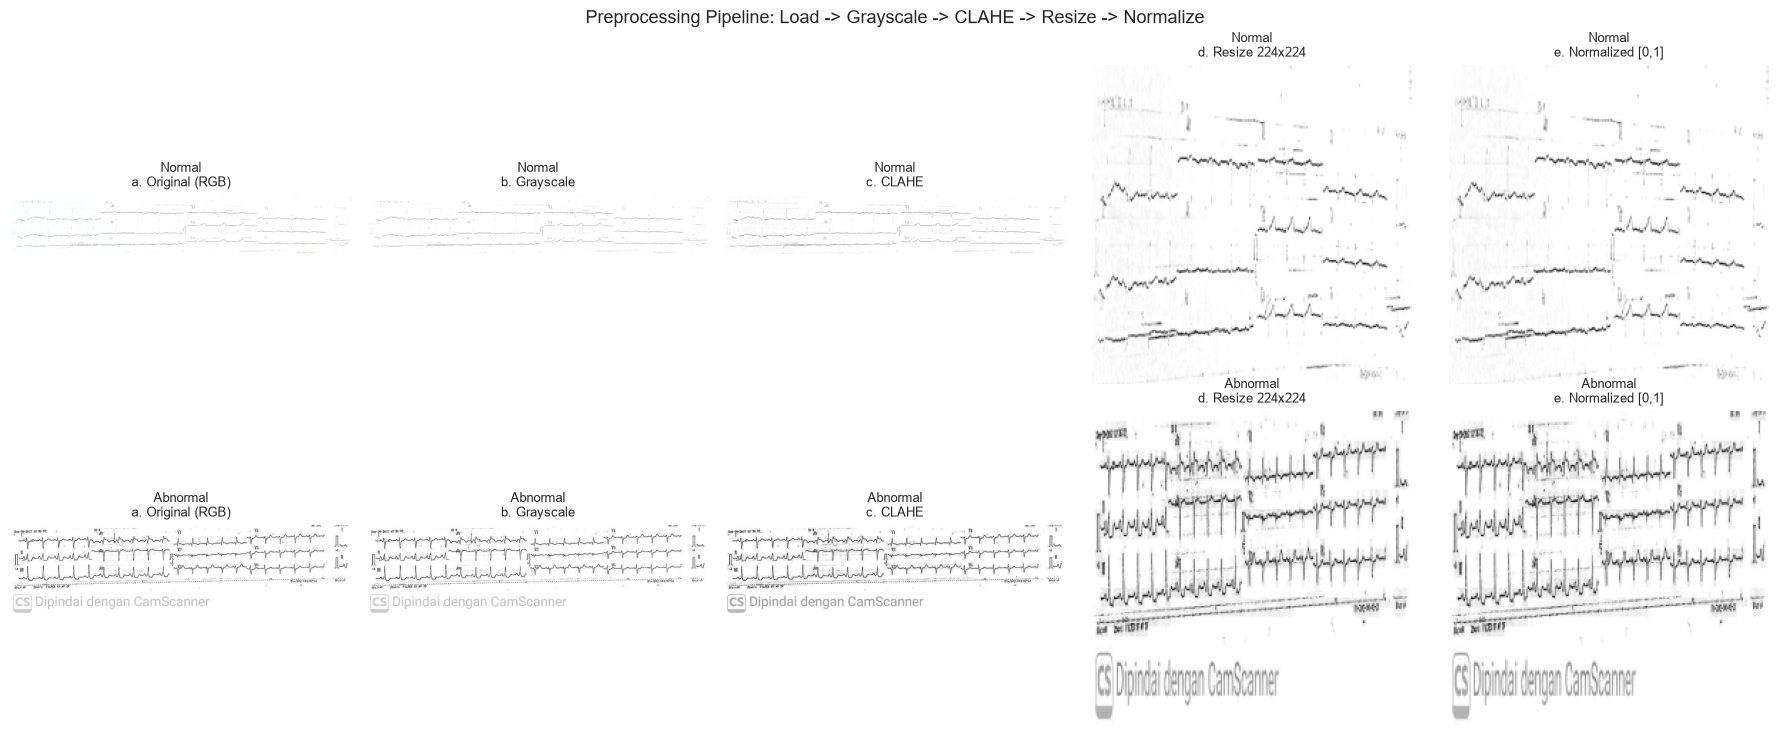

In [9]:
# --- Visualisasi setiap tahap pipeline pada 1 sample Normal & 1 sample Abnormal ---
step_names = ["a. Original (RGB)", "b. Grayscale", "c. CLAHE", "d. Resize 224x224", "e. Normalized [0,1]"]

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

for row, label in enumerate(["Normal", "Abnormal"]):
    sample = df[df["label"] == label].sample(1, random_state=SEED).iloc[0]
    fp = sample["filepath"]

    rgb = load_image(fp)
    gray = to_grayscale(rgb)
    enhanced = apply_clahe(gray)
    resized = resize_image(enhanced)
    normalized = normalize_image(resized)

    steps = [rgb, gray, enhanced, resized, normalized]
    for col, (img, name) in enumerate(zip(steps, step_names)):
        cmap = None if col == 0 else "gray"
        axes[row, col].imshow(img, cmap=cmap)
        axes[row, col].set_title(f"{label}\n{name}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Preprocessing Pipeline: Load -> Grayscale -> CLAHE -> Resize -> Normalize", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# --- Sanity check output preprocess_image() ---
sample_fp = df.iloc[0]["filepath"]
out = preprocess_image(sample_fp)
print("shape :", out.shape)
print("dtype :", out.dtype)
print("min   :", out.min())
print("max   :", out.max())
assert out.shape == (TARGET_SIZE[1], TARGET_SIZE[0])
assert out.dtype == np.float32
assert 0.0 <= out.min() and out.max() <= 1.0
print("\nOK - preprocess_image() sesuai spesifikasi (224x224, float32, [0,1]).")

shape : (224, 224)
dtype : float32
min   : 0.03529412
max   : 1.0

OK - preprocess_image() sesuai spesifikasi (224x224, float32, [0,1]).


## 4. Data Augmentation (Conservative)

Diterapkan **hanya pada data training**, setelah preprocessing (input berupa array `float32` [0,1] ukuran 224×224).

**Geometric (conservative, karena EKG sensitif terhadap distorsi):**
- Rotation ±5°
- Width shift ±5%
- Height shift ±5%
- Zoom ±5%

**Intensity:**
- Brightness [0.95, 1.05]
- Gaussian noise μ=0, σ=0.01
- Gaussian blur kernel=3, σ=[0.1, 0.5]

**Strategi class-specific:** kelas `Abnormal` (minoritas) mendapat augmentasi **1.5× lebih agresif** — parameter di atas dikalikan 1.5 (rotasi jadi ±7.5°, dst.) dan probabilitas penerapan tiap transformasi juga lebih tinggi, supaya persebaran variasi data minoritas lebih besar dibanding kelas `Normal`.

In [11]:
# --- Fungsi augmentasi individual (bekerja pada array float32 [0,1], shape (H, W)) ---

def random_rotate(img: np.ndarray, max_angle: float) -> np.ndarray:
    """Rotation +-max_angle derajat."""
    angle = np.random.uniform(-max_angle, max_angle)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)


def random_shift(img: np.ndarray, max_shift_pct: float) -> np.ndarray:
    """Width & height shift +-max_shift_pct (fraksi lebar/tinggi)."""
    h, w = img.shape[:2]
    tx = np.random.uniform(-max_shift_pct, max_shift_pct) * w
    ty = np.random.uniform(-max_shift_pct, max_shift_pct) * h
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)


def random_zoom(img: np.ndarray, max_zoom_pct: float) -> np.ndarray:
    """Zoom in/out +-max_zoom_pct."""
    h, w = img.shape[:2]
    zoom = 1.0 + np.random.uniform(-max_zoom_pct, max_zoom_pct)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), 0, zoom)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)


def random_brightness(img: np.ndarray, brightness_range: tuple) -> np.ndarray:
    """Brightness scaling dalam brightness_range, hasil di-clip ke [0,1]."""
    factor = np.random.uniform(*brightness_range)
    return np.clip(img * factor, 0.0, 1.0).astype(np.float32)


def add_gaussian_noise(img: np.ndarray, mean: float, sigma: float) -> np.ndarray:
    """Gaussian noise mu=mean, sigma=sigma."""
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    return np.clip(img + noise, 0.0, 1.0).astype(np.float32)


def random_gaussian_blur(img: np.ndarray, kernel_size: int, sigma_range: tuple) -> np.ndarray:
    """Gaussian blur, kernel tetap, sigma acak dalam sigma_range."""
    sigma = np.random.uniform(*sigma_range)
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), sigma)


print("Fungsi augmentasi siap: random_rotate, random_shift, random_zoom,")
print("random_brightness, add_gaussian_noise, random_gaussian_blur")

Fungsi augmentasi siap: random_rotate, random_shift, random_zoom,
random_brightness, add_gaussian_noise, random_gaussian_blur


In [12]:
# --- Parameter dasar & multiplier class-specific ---
BASE_AUG_PARAMS = {
    "rotation_deg": 5.0,
    "shift_pct": 0.05,
    "zoom_pct": 0.05,
    "brightness_delta": 0.05,     # brightness_range = (1-delta, 1+delta) -> [0.95, 1.05]
    "noise_mean": 0.0,
    "noise_sigma": 0.01,
    "blur_kernel": 3,
    "blur_sigma_range": (0.1, 0.5),
    "apply_prob": 0.5,            # probabilitas tiap transformasi diterapkan
}

CLASS_AUG_MULTIPLIER = {
    "Normal": 1.0,     # augmentasi standar
    "Abnormal": 1.5,   # kelas minoritas -> 1.5x lebih agresif
}


def get_augmentation_params(label: str) -> dict:
    """Skala parameter augmentasi dasar sesuai multiplier kelas."""
    mult = CLASS_AUG_MULTIPLIER[label]
    return {
        "rotation_deg": BASE_AUG_PARAMS["rotation_deg"] * mult,
        "shift_pct": BASE_AUG_PARAMS["shift_pct"] * mult,
        "zoom_pct": BASE_AUG_PARAMS["zoom_pct"] * mult,
        "brightness_range": (
            max(0.0, 1 - BASE_AUG_PARAMS["brightness_delta"] * mult),
            1 + BASE_AUG_PARAMS["brightness_delta"] * mult,
        ),
        "noise_mean": BASE_AUG_PARAMS["noise_mean"],
        "noise_sigma": BASE_AUG_PARAMS["noise_sigma"] * mult,
        "blur_kernel": BASE_AUG_PARAMS["blur_kernel"],
        "blur_sigma_range": (
            BASE_AUG_PARAMS["blur_sigma_range"][0],
            BASE_AUG_PARAMS["blur_sigma_range"][1] * mult,
        ),
        "apply_prob": min(1.0, BASE_AUG_PARAMS["apply_prob"] * mult),
    }


def augment_image(img: np.ndarray, label: str) -> np.ndarray:
    """Terapkan augmentasi conservative, tiap transformasi punya peluang `apply_prob`
    untuk aktif, dengan kekuatan mengikuti strategi class-specific."""
    p = get_augmentation_params(label)
    out = img.copy()

    if np.random.rand() < p["apply_prob"]:
        out = random_rotate(out, p["rotation_deg"])
    if np.random.rand() < p["apply_prob"]:
        out = random_shift(out, p["shift_pct"])
    if np.random.rand() < p["apply_prob"]:
        out = random_zoom(out, p["zoom_pct"])
    if np.random.rand() < p["apply_prob"]:
        out = random_brightness(out, p["brightness_range"])
    if np.random.rand() < p["apply_prob"]:
        out = add_gaussian_noise(out, p["noise_mean"], p["noise_sigma"])
    if np.random.rand() < p["apply_prob"]:
        out = random_gaussian_blur(out, p["blur_kernel"], p["blur_sigma_range"])

    return out


print("Normal   params:", get_augmentation_params("Normal"))
print("Abnormal params:", get_augmentation_params("Abnormal"))

Normal   params: {'rotation_deg': 5.0, 'shift_pct': 0.05, 'zoom_pct': 0.05, 'brightness_range': (0.95, 1.05), 'noise_mean': 0.0, 'noise_sigma': 0.01, 'blur_kernel': 3, 'blur_sigma_range': (0.1, 0.5), 'apply_prob': 0.5}
Abnormal params: {'rotation_deg': 7.5, 'shift_pct': 0.07500000000000001, 'zoom_pct': 0.07500000000000001, 'brightness_range': (0.925, 1.075), 'noise_mean': 0.0, 'noise_sigma': 0.015, 'blur_kernel': 3, 'blur_sigma_range': (0.1, 0.75), 'apply_prob': 0.75}


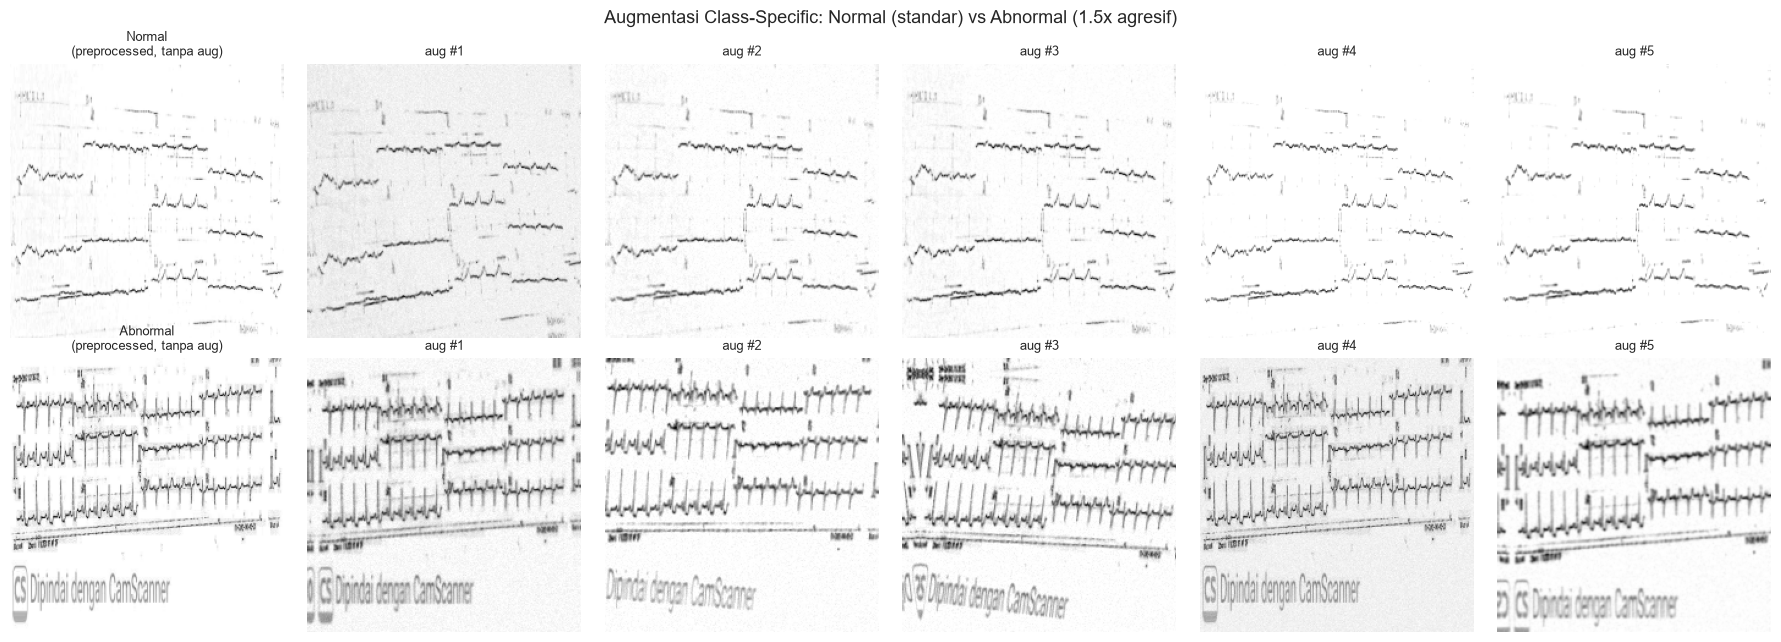

In [13]:
# --- Visualisasi hasil augmentasi: Normal (standar) vs Abnormal (1.5x agresif) ---
np.random.seed(SEED)
n_variants = 5

fig, axes = plt.subplots(2, n_variants + 1, figsize=(3 * (n_variants + 1), 6.5))

for row, label in enumerate(["Normal", "Abnormal"]):
    sample = df[df["label"] == label].sample(1, random_state=SEED).iloc[0]
    base_img = preprocess_image(sample["filepath"])

    axes[row, 0].imshow(base_img, cmap="gray")
    axes[row, 0].set_title(f"{label}\n(preprocessed, tanpa aug)", fontsize=9)
    axes[row, 0].axis("off")

    for v in range(n_variants):
        aug_img = augment_image(base_img, label)
        axes[row, v + 1].imshow(aug_img, cmap="gray")
        axes[row, v + 1].set_title(f"aug #{v + 1}", fontsize=9)
        axes[row, v + 1].axis("off")

plt.suptitle("Augmentasi Class-Specific: Normal (standar) vs Abnormal (1.5x agresif)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. PyTorch Dataset & DataLoader

Membungkus seluruh pipeline (preprocessing + augmentasi khusus training) ke dalam `torch.utils.data.Dataset`, siap dipakai untuk tahap training CNN+Transformer selanjutnya.

In [14]:
LABEL_TO_IDX = {"Normal": 0, "Abnormal": 1}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}


class EKGDataset(Dataset):
    """Dataset EKG: load -> grayscale -> CLAHE -> resize -> normalize -> (augment jika train)."""

    def __init__(self, dataframe: pd.DataFrame, augment: bool = False,
                 target_size: tuple = TARGET_SIZE,
                 clip_limit: float = CLAHE_CLIP_LIMIT,
                 tile_grid_size: tuple = CLAHE_TILE_GRID):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment
        self.target_size = target_size
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = preprocess_image(row["filepath"], self.target_size, self.clip_limit, self.tile_grid_size)

        if self.augment:
            img = augment_image(img, row["label"])

        tensor = torch.from_numpy(img).unsqueeze(0).float()  # (1, H, W)
        label_idx = LABEL_TO_IDX[row["label"]]
        return tensor, label_idx


train_dataset = EKGDataset(df[df["split"] == "train"], augment=True)
test_dataset = EKGDataset(df[df["split"] == "test"], augment=False)

print(f"Train dataset: {len(train_dataset)} samples (augmentasi ON)")
print(f"Test dataset : {len(test_dataset)} samples (augmentasi OFF)")

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Train dataset: 241 samples (augmentasi ON)
Test dataset : 339 samples (augmentasi OFF)


Batch images shape: torch.Size([16, 1, 224, 224])
Batch labels shape: torch.Size([16])
dtype images: torch.float32 | dtype labels: torch.int64
min/max pixel value: 0.0010291878134012222 / 1.0
labels di batch ini: ['Abnormal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Abnormal', 'Normal', 'Normal', 'Normal', 'Abnormal', 'Abnormal', 'Abnormal', 'Normal']


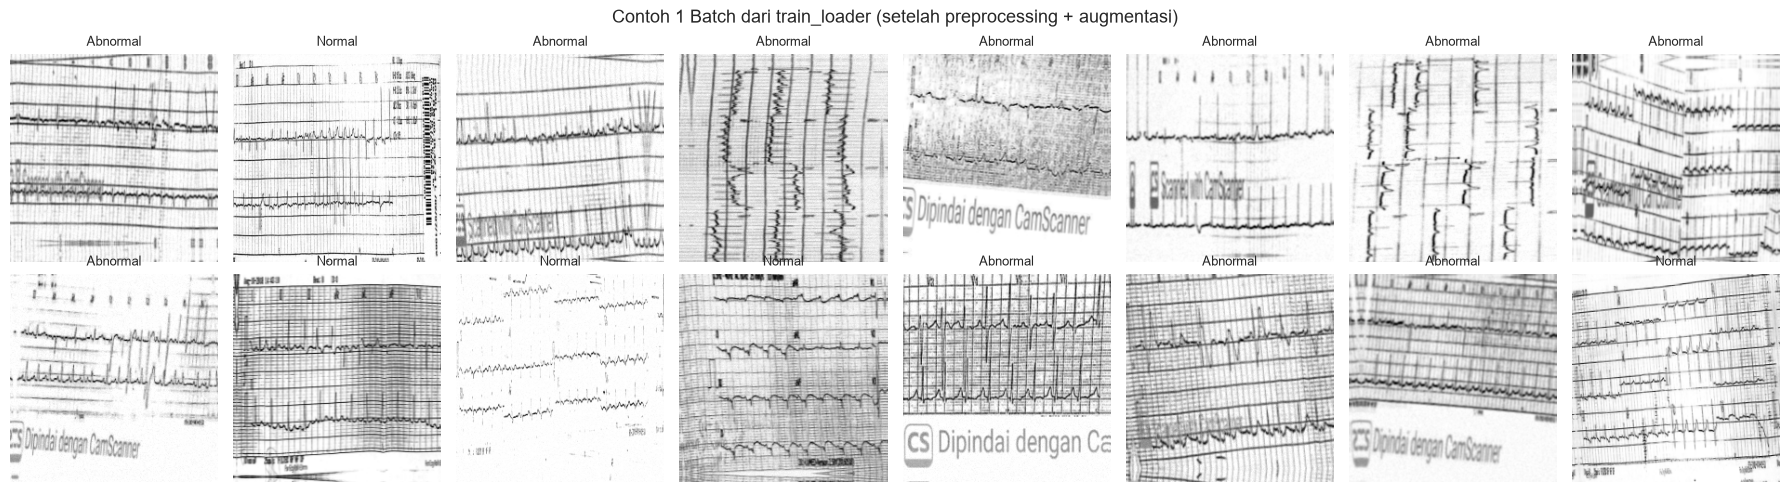

In [15]:
# --- Sanity check: ambil 1 batch dari train_loader ---
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)   # (B, 1, 224, 224)
print("Batch labels shape:", labels.shape)
print("dtype images:", images.dtype, "| dtype labels:", labels.dtype)
print("min/max pixel value:", images.min().item(), "/", images.max().item())
print("labels di batch ini:", [IDX_TO_LABEL[i] for i in labels.tolist()])

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(min(16, images.shape[0])):
    ax = axes[i // 8, i % 8]
    ax.imshow(images[i, 0].numpy(), cmap="gray")
    ax.set_title(IDX_TO_LABEL[labels[i].item()], fontsize=9)
    ax.axis("off")
plt.suptitle("Contoh 1 Batch dari train_loader (setelah preprocessing + augmentasi)", fontsize=13)
plt.tight_layout()
plt.show()

## Ringkasan & Langkah Selanjutnya

Sampai sini sudah selesai:
- Load & validasi dataset (580 citra, 4 folder → `label` + `split`)
- EDA: distribusi kelas, contoh citra, distribusi ukuran, cek color bias
- Preprocessing: grayscale → CLAHE(2.0, 8×8) → resize 224×224 (INTER_AREA) → normalize [0,1] float32
- Augmentasi conservative (geometric + intensity), class-specific 1.5× untuk kelas Abnormal
- `EKGDataset` + `DataLoader` siap dipakai untuk training

**Langkah berikutnya (belum dikerjakan di notebook ini):** desain arsitektur hybrid CNN + Transformer, training loop, evaluasi metrik (accuracy/precision/recall/F1/AUC), dan penanganan ketidakseimbangan kelas lebih lanjut jika diperlukan (lihat catatan di bagian EDA soal rasio train/test yang tidak biasa pada kelas Normal).

---

# Bagian II — Modeling: CNN Baseline vs Hybrid CNN+Transformer

Keputusan yang sudah disepakati sebelumnya:
- **Gabungkan seluruh 580 citra** (folder train/test asli tidak dipakai lagi untuk modeling karena split-nya tidak seimbang), lalu evaluasi dengan **5-fold Stratified Cross-Validation** — setiap fold bergiliran jadi "test", tanpa perlu validation set terpisah.
- **Transfer learning**: backbone CNN memakai **ResNet18 pretrained ImageNet**, bukan dilatih dari nol (data terlalu kecil untuk itu).
- **Tidak ada hyperparameter tuning** — semua setting (epoch, learning rate, dsb) ditetapkan di awal dan dipakai apa adanya di semua fold & kedua model, supaya perbandingan CNN vs Hybrid adil.

## 6. Persiapan Data untuk Modeling

Langkah:
1. Precompute preprocessing (grayscale → CLAHE → resize → normalize) **sekali saja** untuk semua 580 gambar, di-cache di memori (menghindari pengulangan CLAHE yang mahal di setiap fold/epoch).
2. Saat training, cache ini diubah ke **3-channel** (duplikasi grayscale) + **normalisasi ImageNet** (mean/std khusus), karena backbone pretrained mengharapkan input seperti itu.
3. Siapkan **StratifiedKFold(n_splits=5)** dari seluruh data gabungan.

In [16]:
import torch.nn as nn
import torchvision.models as tvm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

# --- 1. Precompute preprocessing sekali untuk semua gambar (cache di memori) ---
print(f"Precomputing preprocessing untuk {len(df)} gambar (grayscale->CLAHE->resize->normalize)...")
cached_images = np.zeros((len(df), TARGET_SIZE[1], TARGET_SIZE[0]), dtype=np.float32)
for i, fp in enumerate(tqdm(df["filepath"], desc="Caching preprocessed images")):
    cached_images[i] = preprocess_image(fp)

all_labels_arr = df["label"].values
print(f"Cache shape: {cached_images.shape}, dtype: {cached_images.dtype}")
print(f"Ukuran memori cache: {cached_images.nbytes / 1e6:.1f} MB")

# --- 2. Konstanta normalisasi ImageNet (dibutuhkan backbone pretrained) ---
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)


class EKGModelDataset(Dataset):
    """Dataset untuk modeling: ambil dari cache (sudah preprocessed), augment jika train,
    lalu ubah ke 3-channel + normalisasi ImageNet."""

    def __init__(self, indices: np.ndarray, augment: bool = False):
        self.indices = indices
        self.augment = augment

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, i: int):
        idx = self.indices[i]
        img = cached_images[idx]
        label_name = all_labels_arr[idx]

        if self.augment:
            img = augment_image(img, label_name)

        img_3ch = np.repeat(img[np.newaxis, :, :], 3, axis=0)          # (1,H,W) -> (3,H,W)
        img_3ch = (img_3ch - IMAGENET_MEAN) / IMAGENET_STD              # normalisasi ImageNet
        tensor = torch.from_numpy(img_3ch).float()
        label_idx = LABEL_TO_IDX[label_name]
        return tensor, label_idx


# --- 3. StratifiedKFold(5) dari seluruh data gabungan ---
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_indices = list(skf.split(np.zeros(len(df)), all_labels_arr))
for fold, (tr_idx, te_idx) in enumerate(fold_indices):
    tr_counts = pd.Series(all_labels_arr[tr_idx]).value_counts().to_dict()
    te_counts = pd.Series(all_labels_arr[te_idx]).value_counts().to_dict()
    print(f"Fold {fold+1}: train={len(tr_idx)} {tr_counts} | test={len(te_idx)} {te_counts}")

Precomputing preprocessing untuk 580 gambar (grayscale->CLAHE->resize->normalize)...


Caching preprocessed images:   0%|          | 0/580 [00:00<?, ?it/s]

Caching preprocessed images:   1%|          | 3/580 [00:00<00:20, 28.56it/s]

Caching preprocessed images:   1%|          | 6/580 [00:00<00:23, 24.23it/s]

Caching preprocessed images:   2%|▏         | 13/580 [00:00<00:14, 39.93it/s]

...

Caching preprocessed images:  97%|█████████▋| 564/580 [00:10<00:00, 44.00it/s]

Caching preprocessed images:  98%|█████████▊| 570/580 [00:10<00:00, 45.52it/s]

Caching preprocessed images:  99%|█████████▉| 576/580 [00:11<00:00, 47.27it/s]

Caching preprocessed images: 100%|██████████| 580/580 [00:11<00:00, 51.87it/s]

Cache shape: (580, 224, 224), dtype: float32
Ukuran memori cache: 116.4 MB
Fold 1: train=464 {'Normal': 301, 'Abnormal': 163} | test=116 {'Normal': 75, 'Abnormal': 41}
Fold 2: train=464 {'Normal': 301, 'Abnormal': 163} | test=116 {'Normal': 75, 'Abnormal': 41}
Fold 3: train=464 {'Normal': 301, 'Abnormal': 163} | test=116 {'Normal': 75, 'Abnormal': 41}
Fold 4: train=464 {'Normal': 301, 'Abnormal': 163} | test=116 {'Normal': 75, 'Abnormal': 41}
Fold 5: train=464 {'Normal': 300, 'Abnormal': 164} | test=116 {'Normal': 76, 'Abnormal': 40}


## 7. Model 1 — CNN Baseline (Transfer Learning)

ResNet18 pretrained ImageNet. Sebagian besar layer **dibekukan** (frozen) — hanya `layer4` (blok terakhir) dan `fc` (classifier head) yang dilatih. Ini strategi transfer learning standar untuk dataset kecil: memanfaatkan fitur umum dari ImageNet, hanya menyesuaikan fitur level-tinggi + keputusan akhir ke domain EKG.

In [17]:
def build_cnn_baseline(num_classes: int = 2) -> nn.Module:
    """ResNet18 pretrained, freeze semua layer kecuali layer4 & fc."""
    model = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)  # fc baru otomatis requires_grad=True
    return model


# Sanity check arsitektur
_tmp = build_cnn_baseline()
n_total = sum(p.numel() for p in _tmp.parameters())
n_trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"CNN Baseline (ResNet18) - total params: {n_total:,} | trainable: {n_trainable:,} "
      f"({n_trainable/n_total*100:.1f}%)")
del _tmp

CNN Baseline (ResNet18) - total params: 11,177,538 | trainable: 8,394,754 (75.1%)


## 8. Model 2 — Hybrid CNN + Transformer

Arsitektur (sesuai diagram yang sudah didiskusikan):
1. **CNN backbone** (ResNet18 pretrained, tanpa `avgpool`/`fc`) → menghasilkan feature map `(B, 512, 7, 7)`.
2. **Tokenisasi** → feature map diratakan jadi 49 token @ 512-dim, ditambah 1 `[CLS]` token + positional embedding.
3. **Transformer Encoder** (2 layer, 8 attention head) → menangkap hubungan antar bagian sinyal EKG.
4. **Classifier head** dari output token `[CLS]`.

Backbone dibekukan sebagian (sama seperti CNN baseline) agar perbandingan adil — perbedaan utama antara kedua model murni terletak pada **ada/tidaknya Transformer**, bukan pada seberapa banyak CNN dilatih ulang.

In [18]:
class CNNTransformerHybrid(nn.Module):
    """ResNet18 backbone (feature extractor) -> tokens + [CLS] + positional embedding
    -> TransformerEncoder -> classifier head."""

    def __init__(self, num_classes: int = 2, num_transformer_layers: int = 2,
                 nhead: int = 8, dropout: float = 0.1):
        super().__init__()
        resnet = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # buang avgpool & fc -> (B,512,7,7)

        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone[-1].parameters():  # layer4 = child terakhir
            param.requires_grad = True

        d_model = 512
        num_patches = 7 * 7

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)                              # (B, 512, 7, 7)
        B = feat.shape[0]
        tokens = feat.flatten(2).transpose(1, 2)              # (B, 49, 512)

        cls = self.cls_token.expand(B, -1, -1)                # (B, 1, 512)
        tokens = torch.cat([cls, tokens], dim=1)              # (B, 50, 512)
        tokens = tokens + self.pos_embed

        encoded = self.transformer(tokens)                   # (B, 50, 512)
        cls_out = self.norm(encoded[:, 0])                   # ambil [CLS]
        return self.classifier(cls_out)


# Sanity check arsitektur + forward pass dummy
_tmp = CNNTransformerHybrid()
n_total = sum(p.numel() for p in _tmp.parameters())
n_trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"Hybrid CNN+Transformer - total params: {n_total:,} | trainable: {n_trainable:,} "
      f"({n_trainable/n_total*100:.1f}%)")

with torch.no_grad():
    dummy_out = _tmp(torch.randn(2, 3, 224, 224))
print("Output shape dummy forward pass:", dummy_out.shape)
del _tmp, dummy_out

Hybrid CNN+Transformer - total params: 15,410,242 | trainable: 12,627,458 (81.9%)
Output shape dummy forward pass: torch.Size([2, 2])


## 9. Training Loop + 5-Fold Cross-Validation

Setting dipakai **sama persis** untuk kedua model & semua fold (tidak ada tuning):
- Optimizer: Adam, learning rate `1e-4`
- Epoch: `12`
- Batch size: `16`
- Loss: `CrossEntropyLoss` dengan **class weight** (mengatasi imbalance Normal:Abnormal), dihitung ulang per fold dari data training fold tersebut saja (menghindari data leakage dari fold test).
- Augmentasi conservative class-specific (Bagian 4) tetap dipakai — hanya pada data training tiap fold.

In [19]:
# --- Hyperparameter tetap (fixed, tidak di-tuning) ---
EPOCHS = 12
LR = 1e-4
BATCH_SIZE_MODEL = 16


def train_one_fold(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader,
                    class_weights: torch.Tensor, epochs: int = EPOCHS, lr: float = LR,
                    device: torch.device = DEVICE):
    """Latih 1 model pada 1 fold, kembalikan history per-epoch + prediksi akhir di test fold."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    y_true, y_pred, y_prob = None, None, None

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        epoch_true, epoch_pred, epoch_prob = [], [], []
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                probs = torch.softmax(outputs, dim=1)[:, 1]
                epoch_true.extend(labels.cpu().numpy())
                epoch_pred.extend(preds.cpu().numpy())
                epoch_prob.extend(probs.cpu().numpy())
        history["test_loss"].append(running_loss / total)
        history["test_acc"].append(correct / total)
        y_true, y_pred, y_prob = np.array(epoch_true), np.array(epoch_pred), np.array(epoch_prob)

    return history, y_true, y_pred, y_prob


def compute_class_weights(train_labels: np.ndarray) -> torch.Tensor:
    """Class weight inverse-frequency, dihitung dari label training fold saja."""
    classes, counts = np.unique(train_labels, return_counts=True)
    weight_map = {c: len(train_labels) / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
    return torch.tensor([weight_map["Normal"], weight_map["Abnormal"]], dtype=torch.float32)


def run_cross_validation(model_builder, model_name: str):
    """Jalankan 5-fold CV untuk 1 model, kembalikan metrik & prediksi tiap fold."""
    fold_metrics, fold_histories = [], []
    labels_cv, preds_cv, probs_cv = [], [], []

    for fold, (train_idx, test_idx) in enumerate(fold_indices):
        print(f"\n=== {model_name} | Fold {fold + 1}/{N_SPLITS} ===")
        torch.manual_seed(SEED + fold)

        class_weights = compute_class_weights(all_labels_arr[train_idx])

        train_loader_fold = DataLoader(
            EKGModelDataset(train_idx, augment=True),
            batch_size=BATCH_SIZE_MODEL, shuffle=True, num_workers=0,
        )
        test_loader_fold = DataLoader(
            EKGModelDataset(test_idx, augment=False),
            batch_size=BATCH_SIZE_MODEL, shuffle=False, num_workers=0,
        )

        model = model_builder()
        history, y_true, y_pred, y_prob = train_one_fold(model, train_loader_fold, test_loader_fold, class_weights)

        fold_histories.append(history)
        labels_cv.append(y_true)
        preds_cv.append(y_pred)
        probs_cv.append(y_prob)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        auc = roc_auc_score(y_true, y_prob)
        fold_metrics.append({"fold": fold + 1, "accuracy": acc, "precision": prec,
                              "recall": rec, "f1": f1, "auc": auc})
        print(f"  acc={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(fold_metrics), fold_histories, labels_cv, preds_cv, probs_cv


print("Fungsi training & 5-fold CV siap dijalankan.")

Fungsi training & 5-fold CV siap dijalankan.


In [20]:
import time

t0 = time.time()
cnn_metrics_df, cnn_histories, cnn_labels_cv, cnn_preds_cv, cnn_probs_cv = run_cross_validation(
    build_cnn_baseline, "CNN Baseline"
)
print(f"\nCNN Baseline selesai dalam {time.time()-t0:.1f} detik")
cnn_metrics_df


=== CNN Baseline | Fold 1/5 ===


  acc=0.828  precision=0.957  recall=0.537  f1=0.688  auc=0.877

=== CNN Baseline | Fold 2/5 ===


  acc=0.810  precision=0.952  recall=0.488  f1=0.645  auc=0.823

=== CNN Baseline | Fold 3/5 ===


  acc=0.879  precision=0.966  recall=0.683  f1=0.800  auc=0.883

=== CNN Baseline | Fold 4/5 ===


  acc=0.871  precision=0.933  recall=0.683  f1=0.789  auc=0.905

=== CNN Baseline | Fold 5/5 ===


  acc=0.828  precision=1.000  recall=0.500  f1=0.667  auc=0.863

CNN Baseline selesai dalam 95.3 detik


,fold,accuracy,precision,recall,f1,auc
0,1,0.827586,0.956522,0.536585,0.687500,0.877398
1,2,0.810345,0.952381,0.487805,0.645161,0.823415
2,3,0.879310,0.965517,0.682927,0.800000,0.882927
3,4,0.870690,0.933333,0.682927,0.788732,0.904715
4,5,0.827586,1.000000,0.500000,0.666667,0.862829


In [21]:
t0 = time.time()
hybrid_metrics_df, hybrid_histories, hybrid_labels_cv, hybrid_preds_cv, hybrid_probs_cv = run_cross_validation(
    lambda: CNNTransformerHybrid(), "CNN+Transformer Hybrid"
)
print(f"\nHybrid CNN+Transformer selesai dalam {time.time()-t0:.1f} detik")
hybrid_metrics_df


=== CNN+Transformer Hybrid | Fold 1/5 ===


  acc=0.871  precision=0.964  recall=0.659  f1=0.783  auc=0.915

=== CNN+Transformer Hybrid | Fold 2/5 ===


  acc=0.802  precision=0.800  recall=0.585  f1=0.676  auc=0.855

=== CNN+Transformer Hybrid | Fold 3/5 ===


  acc=0.845  precision=0.871  recall=0.659  f1=0.750  auc=0.857

=== CNN+Transformer Hybrid | Fold 4/5 ===


  acc=0.879  precision=0.886  recall=0.756  f1=0.816  auc=0.945

=== CNN+Transformer Hybrid | Fold 5/5 ===


  acc=0.802  precision=0.905  recall=0.475  f1=0.623  auc=0.895

Hybrid CNN+Transformer selesai dalam 117.7 detik


,fold,accuracy,precision,recall,f1,auc
0,1,0.870690,0.964286,0.658537,0.782609,0.914797
1,2,0.801724,0.800000,0.585366,0.676056,0.855285
2,3,0.844828,0.870968,0.658537,0.750000,0.856585
3,4,0.879310,0.885714,0.756098,0.815789,0.945366
4,5,0.801724,0.904762,0.475000,0.622951,0.895066


## 10. Evaluasi & Visualisasi Hasil

Metrik yang dilaporkan (per fold, lalu dirata-rata ± std dari 5 fold):
- **Accuracy** — proporsi prediksi benar keseluruhan.
- **Precision** (kelas Abnormal) — dari semua yang diprediksi Abnormal, berapa % benar-benar Abnormal.
- **Recall / Sensitivity** (kelas Abnormal) — dari semua yang benar-benar Abnormal, berapa % berhasil terdeteksi. **Metrik paling kritis** untuk kasus medis (jangan sampai pasien Abnormal terlewat).
- **F1-score** — harmonic mean precision & recall.
- **AUC-ROC** — kemampuan model memisahkan kedua kelas di semua threshold.
- **Confusion Matrix** — rincian benar/salah per kelas.

In [22]:
# --- Tabel ringkasan metrik: mean +- std dari 5 fold, untuk kedua model ---
METRIC_COLS = ["accuracy", "precision", "recall", "f1", "auc"]

def summarize_metrics(metrics_df: pd.DataFrame, model_name: str) -> pd.Series:
    summary = {}
    for col in METRIC_COLS:
        summary[f"{col}_mean"] = metrics_df[col].mean()
        summary[f"{col}_std"] = metrics_df[col].std()
    return pd.Series(summary, name=model_name)

comparison_df = pd.DataFrame([
    summarize_metrics(cnn_metrics_df, "CNN Baseline"),
    summarize_metrics(hybrid_metrics_df, "CNN+Transformer Hybrid"),
])

print("=== Hasil per-fold: CNN Baseline ===")
print(cnn_metrics_df.to_string(index=False))
print("\n=== Hasil per-fold: CNN+Transformer Hybrid ===")
print(hybrid_metrics_df.to_string(index=False))
print("\n=== Ringkasan (mean +- std, 5-fold) ===")
comparison_df

=== Hasil per-fold: CNN Baseline ===
 fold  accuracy  precision   recall       f1      auc
    1  0.827586   0.956522 0.536585 0.687500 0.877398
    2  0.810345   0.952381 0.487805 0.645161 0.823415
    3  0.879310   0.965517 0.682927 0.800000 0.882927
    4  0.870690   0.933333 0.682927 0.788732 0.904715
    5  0.827586   1.000000 0.500000 0.666667 0.862829

=== Hasil per-fold: CNN+Transformer Hybrid ===
 fold  accuracy  precision   recall       f1      auc
    1  0.870690   0.964286 0.658537 0.782609 0.914797
    2  0.801724   0.800000 0.585366 0.676056 0.855285
    3  0.844828   0.870968 0.658537 0.750000 0.856585
    4  0.879310   0.885714 0.756098 0.815789 0.945366
    5  0.801724   0.904762 0.475000 0.622951 0.895066

=== Ringkasan (mean +- std, 5-fold) ===


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std
CNN Baseline,0.843103,0.030111,0.961551,0.024493,0.578049,0.097408,0.717612,0.071759,0.870257,0.030201
CNN+Transformer Hybrid,0.839655,0.036878,0.885146,0.059370,0.626707,0.104274,0.729481,0.078892,0.893420,0.038630


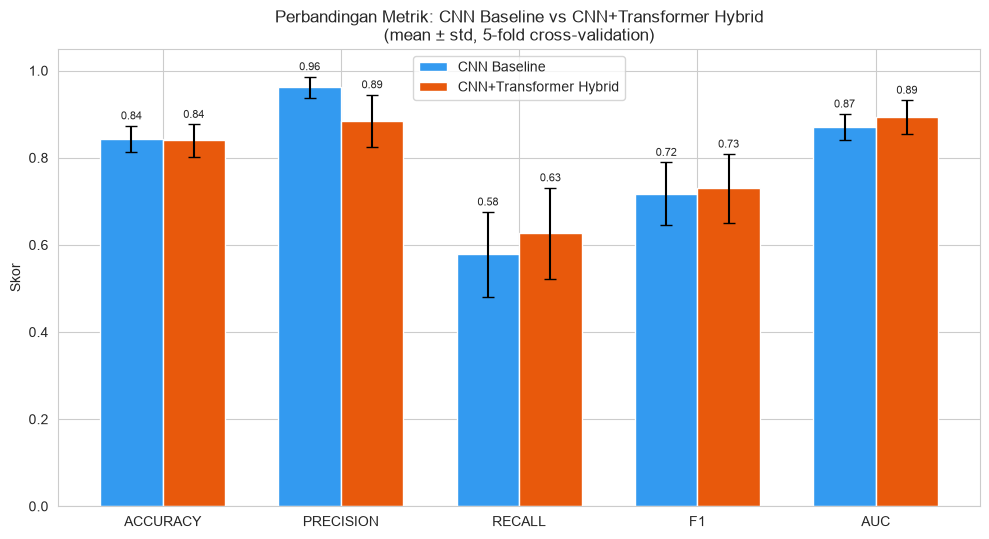

In [23]:
# --- Grafik 1: Bar chart perbandingan metrik (mean +- std) CNN vs Hybrid ---
x = np.arange(len(METRIC_COLS))
width = 0.35

cnn_means = [comparison_df.loc["CNN Baseline", f"{c}_mean"] for c in METRIC_COLS]
cnn_stds = [comparison_df.loc["CNN Baseline", f"{c}_std"] for c in METRIC_COLS]
hybrid_means = [comparison_df.loc["CNN+Transformer Hybrid", f"{c}_mean"] for c in METRIC_COLS]
hybrid_stds = [comparison_df.loc["CNN+Transformer Hybrid", f"{c}_std"] for c in METRIC_COLS]

fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - width/2, cnn_means, width, yerr=cnn_stds, capsize=4, label="CNN Baseline", color="#339af0")
b2 = ax.bar(x + width/2, hybrid_means, width, yerr=hybrid_stds, capsize=4, label="CNN+Transformer Hybrid", color="#e8590c")

ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in METRIC_COLS])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Skor")
ax.set_title("Perbandingan Metrik: CNN Baseline vs CNN+Transformer Hybrid\n(mean ± std, 5-fold cross-validation)")
ax.legend()
ax.bar_label(b1, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.2f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

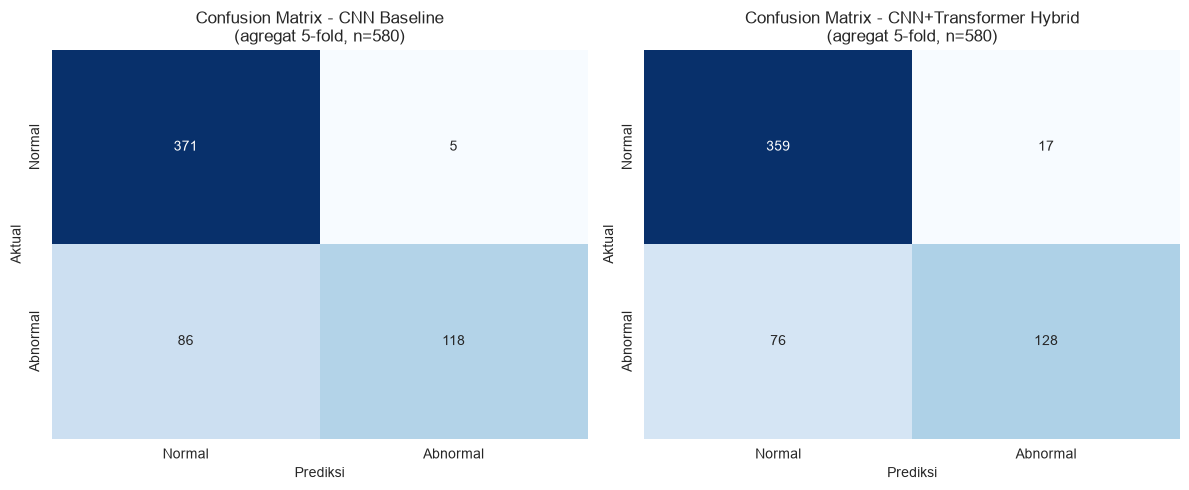

=== Classification Report: CNN Baseline ===
              precision    recall  f1-score   support

      Normal       0.81      0.99      0.89       376
    Abnormal       0.96      0.58      0.72       204

    accuracy                           0.84       580
   macro avg       0.89      0.78      0.81       580
weighted avg       0.86      0.84      0.83       580

=== Classification Report: CNN+Transformer Hybrid ===
              precision    recall  f1-score   support

      Normal       0.83      0.95      0.89       376
    Abnormal       0.88      0.63      0.73       204

    accuracy                           0.84       580
   macro avg       0.85      0.79      0.81       580
weighted avg       0.85      0.84      0.83       580



In [24]:
# --- Grafik 2: Confusion Matrix (agregat seluruh fold = seluruh 580 data, tiap data diprediksi tepat 1x sbg test) ---
cnn_all_true = np.concatenate(cnn_labels_cv)
cnn_all_pred = np.concatenate(cnn_preds_cv)
hybrid_all_true = np.concatenate(hybrid_labels_cv)
hybrid_all_pred = np.concatenate(hybrid_preds_cv)

cm_cnn = confusion_matrix(cnn_all_true, cnn_all_pred)
cm_hybrid = confusion_matrix(hybrid_all_true, hybrid_all_pred)

class_names = [IDX_TO_LABEL[0], IDX_TO_LABEL[1]]  # ["Normal", "Abnormal"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in zip(axes, [cm_cnn, cm_hybrid], ["CNN Baseline", "CNN+Transformer Hybrid"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
    ax.set_title(f"Confusion Matrix - {title}\n(agregat 5-fold, n={cm.sum()})")

plt.tight_layout()
plt.show()

print("=== Classification Report: CNN Baseline ===")
print(classification_report(cnn_all_true, cnn_all_pred, target_names=class_names, zero_division=0))
print("=== Classification Report: CNN+Transformer Hybrid ===")
print(classification_report(hybrid_all_true, hybrid_all_pred, target_names=class_names, zero_division=0))

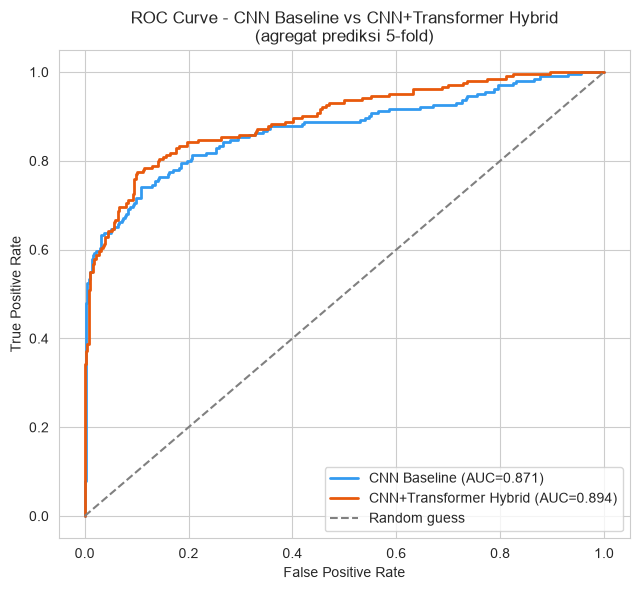

In [25]:
# --- Grafik 3: ROC Curve (agregat prediksi seluruh fold) ---
cnn_all_prob = np.concatenate(cnn_probs_cv)
hybrid_all_prob = np.concatenate(hybrid_probs_cv)

fpr_cnn, tpr_cnn, _ = roc_curve(cnn_all_true, cnn_all_prob)
fpr_hybrid, tpr_hybrid, _ = roc_curve(hybrid_all_true, hybrid_all_prob)
auc_cnn = roc_auc_score(cnn_all_true, cnn_all_prob)
auc_hybrid = roc_auc_score(hybrid_all_true, hybrid_all_prob)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr_cnn, tpr_cnn, label=f"CNN Baseline (AUC={auc_cnn:.3f})", color="#339af0", linewidth=2)
ax.plot(fpr_hybrid, tpr_hybrid, label=f"CNN+Transformer Hybrid (AUC={auc_hybrid:.3f})", color="#e8590c", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - CNN Baseline vs CNN+Transformer Hybrid\n(agregat prediksi 5-fold)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

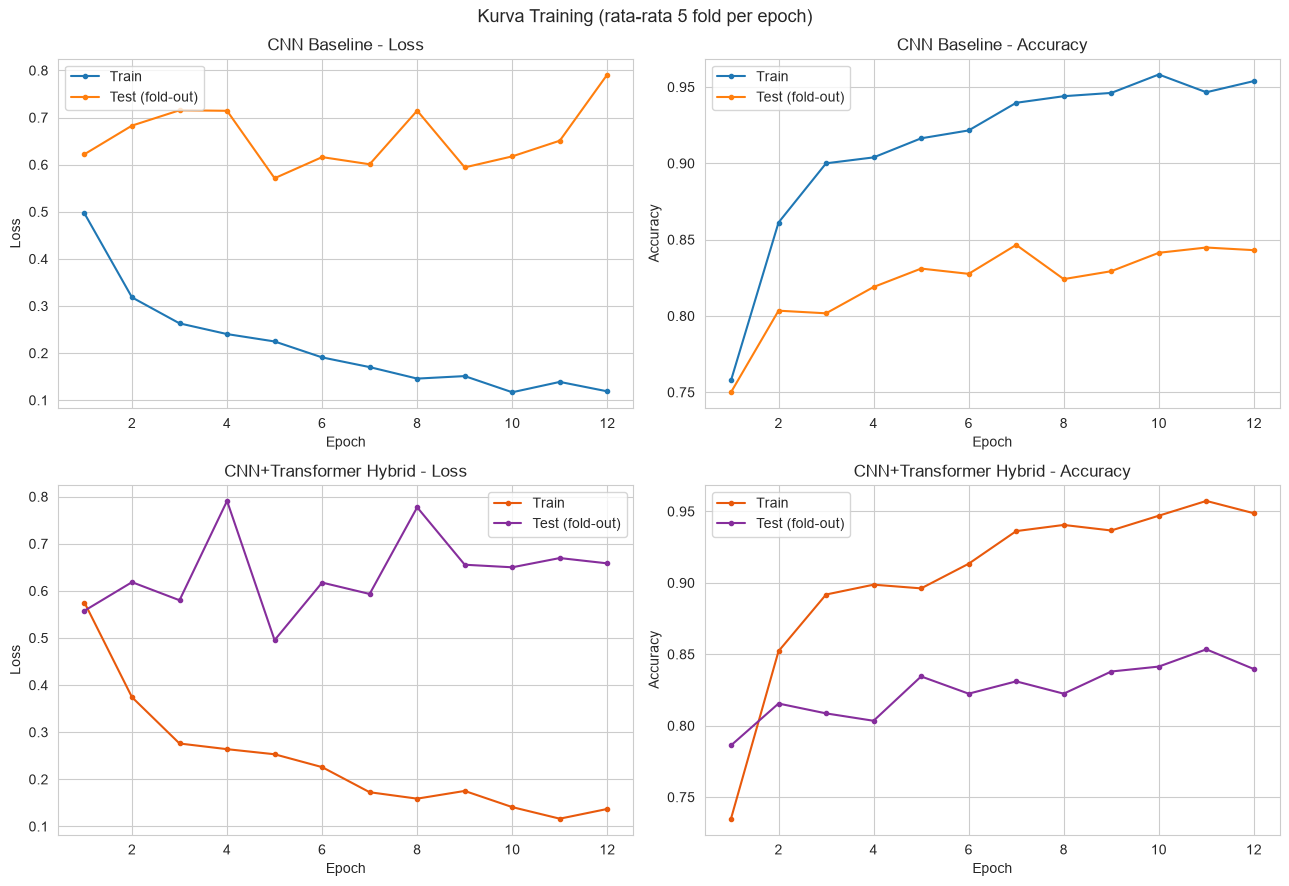

In [26]:
# --- Grafik 4: Training curves (loss & accuracy, dirata-rata antar 5 fold per epoch) ---
def average_history(histories: list) -> dict:
    keys = histories[0].keys()
    return {k: np.mean([h[k] for h in histories], axis=0) for k in keys}

cnn_avg_hist = average_history(cnn_histories)
hybrid_avg_hist = average_history(hybrid_histories)
epochs_range = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(epochs_range, cnn_avg_hist["train_loss"], label="Train", marker="o", markersize=3)
axes[0, 0].plot(epochs_range, cnn_avg_hist["test_loss"], label="Test (fold-out)", marker="o", markersize=3)
axes[0, 0].set_title("CNN Baseline - Loss")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

axes[0, 1].plot(epochs_range, cnn_avg_hist["train_acc"], label="Train", marker="o", markersize=3)
axes[0, 1].plot(epochs_range, cnn_avg_hist["test_acc"], label="Test (fold-out)", marker="o", markersize=3)
axes[0, 1].set_title("CNN Baseline - Accuracy")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy"); axes[0, 1].legend()

axes[1, 0].plot(epochs_range, hybrid_avg_hist["train_loss"], label="Train", marker="o", markersize=3, color="#e8590c")
axes[1, 0].plot(epochs_range, hybrid_avg_hist["test_loss"], label="Test (fold-out)", marker="o", markersize=3, color="#862e9c")
axes[1, 0].set_title("CNN+Transformer Hybrid - Loss")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Loss"); axes[1, 0].legend()

axes[1, 1].plot(epochs_range, hybrid_avg_hist["train_acc"], label="Train", marker="o", markersize=3, color="#e8590c")
axes[1, 1].plot(epochs_range, hybrid_avg_hist["test_acc"], label="Test (fold-out)", marker="o", markersize=3, color="#862e9c")
axes[1, 1].set_title("CNN+Transformer Hybrid - Accuracy")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy"); axes[1, 1].legend()

plt.suptitle("Kurva Training (rata-rata 5 fold per epoch)", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# --- Kesimpulan otomatis berdasarkan hasil aktual di atas (bukan teks statis) ---
def fmt(v):
    return f"{v:.3f}"

better_acc = "CNN+Transformer Hybrid" if comparison_df.loc["CNN+Transformer Hybrid", "accuracy_mean"] > comparison_df.loc["CNN Baseline", "accuracy_mean"] else "CNN Baseline"
better_recall = "CNN+Transformer Hybrid" if comparison_df.loc["CNN+Transformer Hybrid", "recall_mean"] > comparison_df.loc["CNN Baseline", "recall_mean"] else "CNN Baseline"
better_auc = "CNN+Transformer Hybrid" if comparison_df.loc["CNN+Transformer Hybrid", "auc_mean"] > comparison_df.loc["CNN Baseline", "auc_mean"] else "CNN Baseline"

cnn_gap = cnn_avg_hist["train_acc"][-1] - cnn_avg_hist["test_acc"][-1]
hybrid_gap = hybrid_avg_hist["train_acc"][-1] - hybrid_avg_hist["test_acc"][-1]

print("=" * 70)
print("KESIMPULAN OTOMATIS (berdasarkan hasil run di atas)")
print("=" * 70)
print(f"\n1. Accuracy rata-rata lebih tinggi  : {better_acc}")
print(f"   CNN Baseline   : {fmt(comparison_df.loc['CNN Baseline','accuracy_mean'])} +- {fmt(comparison_df.loc['CNN Baseline','accuracy_std'])}")
print(f"   Hybrid         : {fmt(comparison_df.loc['CNN+Transformer Hybrid','accuracy_mean'])} +- {fmt(comparison_df.loc['CNN+Transformer Hybrid','accuracy_std'])}")

print(f"\n2. Recall kelas Abnormal (paling kritis di kasus medis) lebih tinggi: {better_recall}")
print(f"   CNN Baseline   : {fmt(comparison_df.loc['CNN Baseline','recall_mean'])} +- {fmt(comparison_df.loc['CNN Baseline','recall_std'])}")
print(f"   Hybrid         : {fmt(comparison_df.loc['CNN+Transformer Hybrid','recall_mean'])} +- {fmt(comparison_df.loc['CNN+Transformer Hybrid','recall_std'])}")

print(f"\n3. AUC-ROC lebih tinggi             : {better_auc}")
print(f"   CNN Baseline   : {fmt(comparison_df.loc['CNN Baseline','auc_mean'])}")
print(f"   Hybrid         : {fmt(comparison_df.loc['CNN+Transformer Hybrid','auc_mean'])}")

print(f"\n4. Gap train-test accuracy (indikasi overfitting, epoch terakhir):")
print(f"   CNN Baseline   : {fmt(cnn_gap)}  {'<- gap besar, waspada overfitting' if cnn_gap > 0.15 else ''}")
print(f"   Hybrid         : {fmt(hybrid_gap)}  {'<- gap besar, waspada overfitting' if hybrid_gap > 0.15 else ''}")

print("\n" + "=" * 70)
print("SARAN (tanpa tuning, berdasarkan hasil ini)")
print("=" * 70)
print("""
- Jika Hybrid TIDAK mengungguli CNN Baseline secara meyakinkan: ini wajar untuk
  dataset sekecil ini (580 citra). Transformer butuh data lebih banyak untuk
  menunjukkan keunggulannya menangkap hubungan global antar bagian sinyal.
- Jika gap train-test accuracy besar pada salah satu model: model overfit ke data
  training. Opsi ke depan (bukan bagian scope saat ini): tambah data, regularisasi
  (dropout lebih besar / weight decay), atau augmentasi lebih agresif.
- Perhatikan recall Abnormal secara khusus: accuracy tinggi bisa menipu jika model
  cenderung menebak Normal (kelas mayoritas). Confusion matrix di atas menunjukkan
  rincian kesalahan tiap kelas.
- Untuk kesimpulan yang lebih kuat secara statistik, idealnya perbedaan CNN vs
  Hybrid diuji dengan uji signifikansi (mis. paired t-test antar fold) -- belum
  dilakukan di sini karena di luar scope saat ini.
""")

KESIMPULAN OTOMATIS (berdasarkan hasil run di atas)

1. Accuracy rata-rata lebih tinggi  : CNN Baseline
   CNN Baseline   : 0.843 +- 0.030
   Hybrid         : 0.840 +- 0.037

2. Recall kelas Abnormal (paling kritis di kasus medis) lebih tinggi: CNN+Transformer Hybrid
   CNN Baseline   : 0.578 +- 0.097
   Hybrid         : 0.627 +- 0.104

3. AUC-ROC lebih tinggi             : CNN+Transformer Hybrid
   CNN Baseline   : 0.870
   Hybrid         : 0.893

4. Gap train-test accuracy (indikasi overfitting, epoch terakhir):
   CNN Baseline   : 0.111  
   Hybrid         : 0.109  

SARAN (tanpa tuning, berdasarkan hasil ini)

- Jika Hybrid TIDAK mengungguli CNN Baseline secara meyakinkan: ini wajar untuk
  dataset sekecil ini (580 citra). Transformer butuh data lebih banyak untuk
  menunjukkan keunggulannya menangkap hubungan global antar bagian sinyal.
- Jika gap train-test accuracy besar pada salah satu model: model overfit ke data
  training. Opsi ke depan (bukan bagian scope saat ini): tambah 

---

# Bagian III — Visualisasi Evaluasi Tambahan

Tiga visualisasi tambahan untuk memperdalam analisis performa CNN Baseline vs Hybrid CNN+Transformer, melengkapi Bagian 7 (Bar Chart, Confusion Matrix, ROC Curve, Training Curves).

## 12. Precision vs Recall per Fold (5-Fold CV)

Line chart yang menghubungkan titik precision-recall tiap fold secara berurutan (Fold 1 -> 5), untuk memvisualisasikan langsung trade-off precision-recall dan konsistensi antar fold pada kedua model.

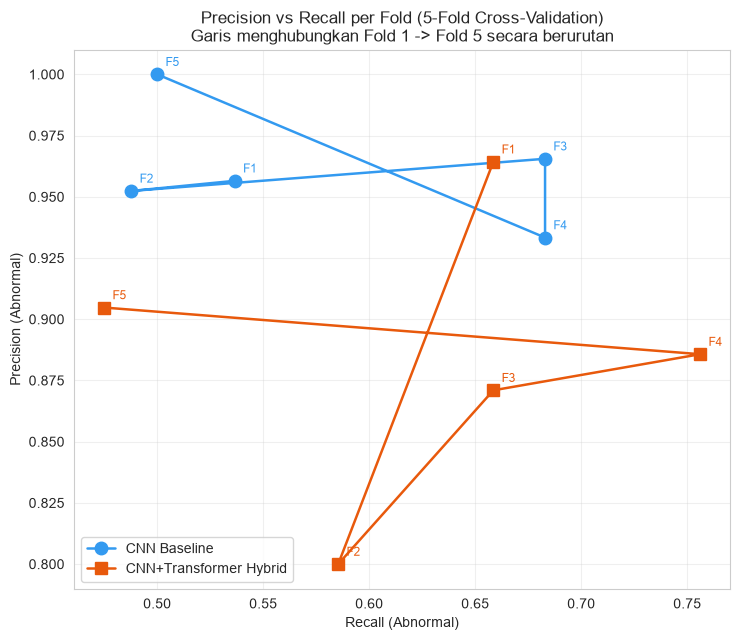

Interpretasi: titik yang berkerumun di kiri-atas (precision tinggi, recall rendah) menunjukkan
model konservatif; titik yang lebih ke kanan menunjukkan model lebih berani mendeteksi Abnormal.


In [28]:
# --- Grafik 5: Precision (y) vs Recall (x) per Fold, garis mengikuti urutan fold ---
fig, ax = plt.subplots(figsize=(7.5, 6.5))

for dfm, label, color, marker in [
    (cnn_metrics_df, "CNN Baseline", "#339af0", "o"),
    (hybrid_metrics_df, "CNN+Transformer Hybrid", "#e8590c", "s"),
]:
    dfm_sorted = dfm.sort_values("fold")
    ax.plot(dfm_sorted["recall"], dfm_sorted["precision"], marker=marker, linestyle="-",
            color=color, label=label, markersize=9, linewidth=1.8)
    for _, row in dfm_sorted.iterrows():
        ax.annotate(f"F{int(row['fold'])}", (row["recall"], row["precision"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=8.5, color=color)

ax.set_xlabel("Recall (Abnormal)")
ax.set_ylabel("Precision (Abnormal)")
ax.set_title("Precision vs Recall per Fold (5-Fold Cross-Validation)\nGaris menghubungkan Fold 1 -> Fold 5 secara berurutan")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretasi: titik yang berkerumun di kiri-atas (precision tinggi, recall rendah) menunjukkan")
print("model konservatif; titik yang lebih ke kanan menunjukkan model lebih berani mendeteksi Abnormal.")

## 13. Calibration Curve (Reliability Diagram)

Mengukur apakah probabilitas yang dikeluarkan model bisa dipercaya secara harfiah: sumbu-X = probabilitas prediksi rata-rata per bin, sumbu-Y = proporsi aktual Abnormal pada bin tersebut. Kalibrasi sempurna = mengikuti garis diagonal. Dilengkapi Brier Score (semakin rendah semakin baik).

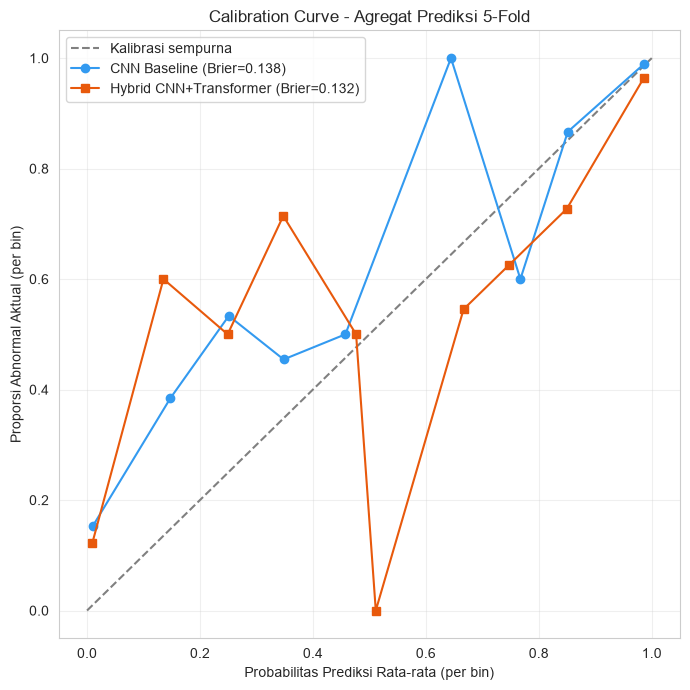

Brier Score CNN Baseline            : 0.1381
Brier Score CNN+Transformer Hybrid  : 0.1319
(Brier Score lebih rendah = probabilitas prediksi lebih dapat dipercaya)


In [29]:
# --- Grafik 6: Calibration Curve (Reliability Diagram) ---
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos_cnn, mean_pred_cnn = calibration_curve(cnn_all_true, cnn_all_prob, n_bins=10, strategy="uniform")
frac_pos_hybrid, mean_pred_hybrid = calibration_curve(hybrid_all_true, hybrid_all_prob, n_bins=10, strategy="uniform")

brier_cnn = brier_score_loss(cnn_all_true, cnn_all_prob)
brier_hybrid = brier_score_loss(hybrid_all_true, hybrid_all_prob)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Kalibrasi sempurna")
ax.plot(mean_pred_cnn, frac_pos_cnn, "o-", color="#339af0",
        label=f"CNN Baseline (Brier={brier_cnn:.3f})")
ax.plot(mean_pred_hybrid, frac_pos_hybrid, "s-", color="#e8590c",
        label=f"Hybrid CNN+Transformer (Brier={brier_hybrid:.3f})")
ax.set_xlabel("Probabilitas Prediksi Rata-rata (per bin)")
ax.set_ylabel("Proporsi Abnormal Aktual (per bin)")
ax.set_title("Calibration Curve - Agregat Prediksi 5-Fold")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Brier Score CNN Baseline            : {brier_cnn:.4f}")
print(f"Brier Score CNN+Transformer Hybrid  : {brier_hybrid:.4f}")
print("(Brier Score lebih rendah = probabilitas prediksi lebih dapat dipercaya)")

## 14. Decision Curve Analysis (DCA)

Mengukur manfaat klinis (net benefit) model dibanding dua strategi ekstrem: **Treat All** (anggap semua pasien Abnormal) dan **Treat None** (anggap semua Normal), pada rentang threshold probabilitas keputusan. Model yang berguna secara klinis akan berada di atas kedua strategi ekstrem pada rentang threshold yang wajar.

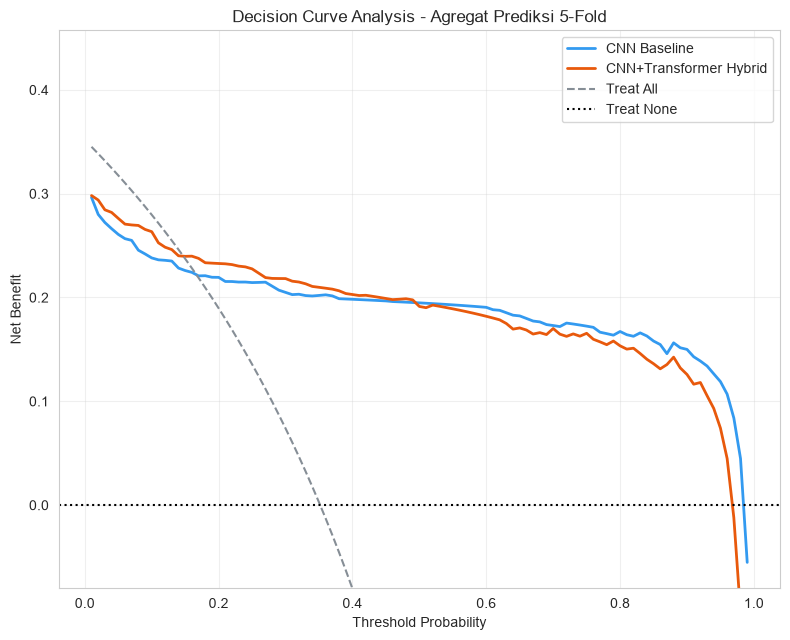

Interpretasi: kurva model yang berada di atas Treat All dan Treat None pada rentang
threshold tertentu menunjukkan model memberi manfaat klinis nyata pada rentang tersebut.
(Sumbu-Y dibatasi ke [-0.08, 0.46] agar bagian bermakna klinis tetap terbaca jelas)


In [30]:
# --- Grafik 7: Decision Curve Analysis (DCA) ---
def decision_curve_analysis(y_true, y_prob, thresholds):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    prevalence = y_true.mean()
    nb_model, nb_all = [], []
    for pt in thresholds:
        preds = (y_prob >= pt).astype(int)
        tp = np.sum((preds == 1) & (y_true == 1))
        fp = np.sum((preds == 1) & (y_true == 0))
        odds = pt / (1 - pt)
        nb_model.append(tp / n - fp / n * odds)
        nb_all.append(prevalence - (1 - prevalence) * odds)
    return np.array(nb_model), np.array(nb_all)

thresholds = np.linspace(0.01, 0.99, 99)
nb_cnn, nb_all_ref = decision_curve_analysis(cnn_all_true, cnn_all_prob, thresholds)
nb_hybrid, _ = decision_curve_analysis(hybrid_all_true, hybrid_all_prob, thresholds)

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.plot(thresholds, nb_cnn, color="#339af0", linewidth=2, label="CNN Baseline")
ax.plot(thresholds, nb_hybrid, color="#e8590c", linewidth=2, label="CNN+Transformer Hybrid")
ax.plot(thresholds, nb_all_ref, color="#868e96", linestyle="--", linewidth=1.5, label="Treat All")
ax.axhline(0, color="black", linestyle=":", linewidth=1.5, label="Treat None")

# Batas sumbu-Y ditetapkan eksplisit (bukan autoscale) karena Treat All meledak negatif
# saat threshold mendekati 1 (odds = pt/(1-pt) -> tak hingga), yang akan merusak skala
# tampilan bagian kurva yang sebenarnya bermakna secara klinis.
prevalence = np.mean(cnn_all_true)
y_top = max(nb_cnn.max(), nb_hybrid.max(), prevalence) * 1.3
ax.set_ylim(-0.08, y_top)

ax.set_xlabel("Threshold Probability")
ax.set_ylabel("Net Benefit")
ax.set_title("Decision Curve Analysis - Agregat Prediksi 5-Fold")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretasi: kurva model yang berada di atas Treat All dan Treat None pada rentang")
print("threshold tertentu menunjukkan model memberi manfaat klinis nyata pada rentang tersebut.")
print(f"(Sumbu-Y dibatasi ke [-0.08, {y_top:.2f}] agar bagian bermakna klinis tetap terbaca jelas)")


## 15. Explainability: Grad-CAM & Attention Analysis

Bagian ini membandingkan **apa yang dilihat** tiap model saat mengklasifikasikan sebuah citra EKG:

- **CNN Baseline** -> Grad-CAM pada `layer4` (target kelas = Abnormal).
- **CNN+Transformer Hybrid** -> dua tampilan pelengkap:
  1. **Grad-CAM** pada backbone yang sama (`layer4`, target kelas = Abnormal). Karena gradiennya
     mengalir *melewati* Transformer sampai ke `layer4`, ini adalah Grad-CAM **full-model** yang
     berbasis di titik yang sama dengan CNN Baseline -> perbandingan Grad-CAM CNN vs Hybrid jadi adil
     (metode & layer sama).
  2. **Attention Rollout** (CLS -> 49 token patch, digabung lintas 2 layer TransformerEncoder) ->
     tampilan unik milik Hybrid yang menunjukkan wilayah spasial mana yang dipakai tahap reasoning
     global (Transformer).

Ketiga peta berada pada **grid spasial 7x7 yang sama** (`(B,512,7,7)` keluaran backbone -> 49 token),
sehingga bisa di-upsample ke 224x224 dan dibandingkan sel demi sel secara adil.

**Catatan penting (reprodusibilitas):** peta di bagian ini dihasilkan dari bobot model yang dilatih
ulang khusus pada **Fold 1** (menggunakan `fold_indices` & hyperparameter tetap yang identik dengan
`run_cross_validation()` di atas -- tanpa tuning). Ini ilustratif untuk satu fold, bukan rata-rata/
ensemble 5-fold. Sample yang divisualisasikan diambil dari **held-out test split Fold 1** sehingga
status benar/salah prediksi bersifat out-of-sample, bukan hasil menghafal data training.

Tidak ada retraining tambahan untuk menghasilkan attention weights -- `forward_with_attention()` di
bawah murni menjalankan ulang submodule yang sama (`self_attn`, dll.) dengan `need_weights=True` secara
inference-only, karena `nn.TransformerEncoderLayer` bawaan PyTorch selalu memanggil `self_attn` dengan
`need_weights=False` sehingga attention matrix normalnya tidak pernah disimpan.

In [31]:
# --- 15.1 Retrain fold-1 models (CNN & Hybrid) khusus untuk analisis explainability ---
# Fold yang sama dari StratifiedKFold (fold_indices[0]) yang dipakai run_cross_validation() di atas.
# Bobot hasil training ini HANYA untuk visualisasi Grad-CAM/Attention -- ilustratif satu fold,
# bukan ensemble 5-fold. Hyperparameter identik (EPOCHS, LR, BATCH_SIZE_MODEL, class-weighted loss).

EXPLAIN_FOLD = 0  # fold ke-1 (index 0)
explain_train_idx, explain_test_idx = fold_indices[EXPLAIN_FOLD]
explain_labels = all_labels_arr[explain_test_idx]

explain_class_weights = compute_class_weights(all_labels_arr[explain_train_idx])

explain_train_loader = DataLoader(
    EKGModelDataset(explain_train_idx, augment=True),
    batch_size=BATCH_SIZE_MODEL, shuffle=True, num_workers=0,
)
explain_test_loader = DataLoader(
    EKGModelDataset(explain_test_idx, augment=False),
    batch_size=BATCH_SIZE_MODEL, shuffle=False, num_workers=0,
)

print(f"Melatih ulang model Fold {EXPLAIN_FOLD + 1} untuk analisis explainability "
      f"(train={len(explain_train_idx)}, test={len(explain_test_idx)})...")

torch.manual_seed(SEED + EXPLAIN_FOLD)
cnn_explain_model = build_cnn_baseline()
_, cnn_explain_true, cnn_explain_pred, cnn_explain_prob = train_one_fold(
    cnn_explain_model, explain_train_loader, explain_test_loader, explain_class_weights
)
cnn_explain_model.eval()

torch.manual_seed(SEED + EXPLAIN_FOLD)
hybrid_explain_model = CNNTransformerHybrid()
_, hybrid_explain_true, hybrid_explain_pred, hybrid_explain_prob = train_one_fold(
    hybrid_explain_model, explain_train_loader, explain_test_loader, explain_class_weights
)
hybrid_explain_model.eval()

print(f"\nFold {EXPLAIN_FOLD + 1} explainability models siap.")
print(f"  CNN Baseline  - acc: {accuracy_score(cnn_explain_true, cnn_explain_pred):.3f}  "
      f"recall(Abnormal): {recall_score(cnn_explain_true, cnn_explain_pred, pos_label=1, zero_division=0):.3f}")
print(f"  Hybrid        - acc: {accuracy_score(hybrid_explain_true, hybrid_explain_pred):.3f}  "
      f"recall(Abnormal): {recall_score(hybrid_explain_true, hybrid_explain_pred, pos_label=1, zero_division=0):.3f}")

Melatih ulang model Fold 1 untuk analisis explainability (train=464, test=116)...



Fold 1 explainability models siap.
  CNN Baseline  - acc: 0.862  recall(Abnormal): 0.707
  Hybrid        - acc: 0.879  recall(Abnormal): 0.707


In [32]:
# --- 15.2 Grad-CAM helper (dipakai untuk CNN Baseline & backbone Hybrid) ---
class GradCAM:
    """Grad-CAM pada satu target module (mis. layer4 ResNet). Hook forward+backward hanya
    aktif selama context manager berjalan agar tidak membebani forward pass lain di notebook."""

    def __init__(self, model: nn.Module, target_module: nn.Module):
        self.model = model
        self.target_module = target_module
        self.activations = None
        self.gradients = None
        self._fwd_handle = None
        self._bwd_handle = None

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __enter__(self):
        self._fwd_handle = self.target_module.register_forward_hook(self._save_activation)
        self._bwd_handle = self.target_module.register_full_backward_hook(self._save_gradient)
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self._fwd_handle.remove()
        self._bwd_handle.remove()

    def compute(self, input_tensor: torch.Tensor, target_class: int = 1) -> np.ndarray:
        """input_tensor: (1, 3, H, W). Mengembalikan CAM pada resolusi grid aktivasi native
        (mis. 7x7 untuk ResNet18/224px), dinormalisasi ke [0, 1]. Upsampling dilakukan terpisah
        supaya metrik kuantitatif (Bagian 15.7) tetap dihitung pada resolusi token asli (49 sel)."""
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, target_class]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)                      # (1, C, 1, 1)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))[0, 0]  # (h, w)
        cam = cam.cpu().numpy()
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)
        return cam


def compute_gradcam(model: nn.Module, target_module: nn.Module, input_tensor: torch.Tensor,
                     target_class: int = 1) -> np.ndarray:
    model.eval()
    with GradCAM(model, target_module) as gc:
        return gc.compute(input_tensor, target_class)


def map_to_grid(map_1d: np.ndarray, grid_size: int = 7) -> np.ndarray:
    return map_1d.reshape(grid_size, grid_size)


def upsample_map(map_2d: np.ndarray, size: tuple = TARGET_SIZE) -> np.ndarray:
    m = cv2.resize(map_2d.astype(np.float32), size, interpolation=cv2.INTER_CUBIC)
    m = np.clip(m, 0, None)
    m_min, m_max = m.min(), m.max()
    if m_max - m_min > 1e-8:
        m = (m - m_min) / (m_max - m_min)
    return m


print("GradCAM helper siap (target kelas default = Abnormal / index 1).")

GradCAM helper siap (target kelas default = Abnormal / index 1).


In [33]:
# --- 15.3 Attention rollout untuk Hybrid: recompute attention weights secara inference-only ---
# nn.TransformerEncoderLayer bawaan selalu memanggil self_attn(..., need_weights=False), sehingga
# hook biasa tidak bisa menangkap attention matrix. Fungsi di bawah menjalankan ulang forward pass
# TransformerEncoderLayer secara manual (memakai submodule yang SAMA & SUDAH TERLATIH -- self_attn,
# linear1/2, norm1/2, dropout) sambil meminta attention weights. Tidak ada parameter baru/berubah,
# jadi logits yang dihasilkan harus identik dengan model.forward() -- diverifikasi di sel berikutnya.

def transformer_layer_forward_with_attn(layer: nn.TransformerEncoderLayer, x: torch.Tensor):
    """Re-implementasi forward nn.TransformerEncoderLayer (post-norm, batch_first=True)
    sesuai implementasi resmi PyTorch, sambil mengembalikan attention weights per-head."""
    attn_out, attn_weights = layer.self_attn(
        x, x, x, need_weights=True, average_attn_weights=False
    )  # attn_weights: (B, nhead, T, T)
    x = layer.norm1(x + layer.dropout1(attn_out))
    ff = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
    x = layer.norm2(x + layer.dropout2(ff))
    return x, attn_weights


def forward_with_attention(model: "CNNTransformerHybrid", x: torch.Tensor):
    """Forward pass CNNTransformerHybrid sambil mengumpulkan attention weights tiap layer
    TransformerEncoder. Murni re-run submodule yang sama untuk inference (tanpa retraining)."""
    feat = model.backbone(x)                              # (B, 512, 7, 7)
    B = feat.shape[0]
    tokens = feat.flatten(2).transpose(1, 2)              # (B, 49, 512)

    cls = model.cls_token.expand(B, -1, -1)
    tokens = torch.cat([cls, tokens], dim=1)              # (B, 50, 512)
    tokens = tokens + model.pos_embed

    attn_weights_per_layer = []
    out = tokens
    for layer in model.transformer.layers:
        out, attn_w = transformer_layer_forward_with_attn(layer, out)
        attn_weights_per_layer.append(attn_w)
    if model.transformer.norm is not None:
        out = model.transformer.norm(out)

    cls_out = model.norm(out[:, 0])
    logits = model.classifier(cls_out)
    return logits, attn_weights_per_layer


def attention_rollout(attn_weights_per_layer: list) -> np.ndarray:
    """Attention rollout (Abnar & Zuidema, 2020) lintas layer TransformerEncoder.
    Mengembalikan distribusi CLS->patch (panjang 49, non-negatif, sum=1)."""
    T = attn_weights_per_layer[0].shape[-1]
    eye = torch.eye(T, device=attn_weights_per_layer[0].device)

    rollout = eye
    for attn_w in attn_weights_per_layer:
        attn_avg = attn_w[0].mean(dim=0)              # (T, T), rata-rata antar head
        attn_hat = 0.5 * attn_avg + 0.5 * eye          # perhitungkan residual connection
        attn_hat = attn_hat / attn_hat.sum(dim=-1, keepdim=True)
        rollout = attn_hat @ rollout

    cls_to_patches = rollout[0, 1:]                    # baris CLS, buang kolom CLS-self
    cls_to_patches = cls_to_patches / cls_to_patches.sum()
    return cls_to_patches.cpu().numpy()


print("Attention rollout helper siap (CLS -> 49 patch token, lintas 2 layer TransformerEncoder).")

Attention rollout helper siap (CLS -> 49 patch token, lintas 2 layer TransformerEncoder).


In [34]:
# --- 15.3b Sanity check forward_with_attention() vs forward() biasa (verifikasi tanpa retraining) ---
def make_input_tensor(idx: int) -> torch.Tensor:
    """Bangun tensor input (1,3,H,W) siap-model dari cache preprocessed (tanpa augmentasi),
    dengan langkah yang sama seperti EKGModelDataset: replikasi 3-channel + normalisasi ImageNet."""
    img = cached_images[idx]
    img_3ch = np.repeat(img[np.newaxis, :, :], 3, axis=0)
    img_3ch = (img_3ch - IMAGENET_MEAN) / IMAGENET_STD
    tensor = torch.from_numpy(img_3ch).float().unsqueeze(0)
    return tensor.to(DEVICE)


hybrid_explain_model.eval()
_sanity_x = make_input_tensor(explain_test_idx[0])
with torch.no_grad():
    logits_normal = hybrid_explain_model(_sanity_x)
    logits_attn, _attn_check = forward_with_attention(hybrid_explain_model, _sanity_x)

max_abs_diff = (logits_normal - logits_attn).abs().max().item()
print(f"Max abs diff logits (forward biasa vs forward_with_attention): {max_abs_diff:.2e}")
assert max_abs_diff < 1e-4, "forward_with_attention() tidak konsisten dengan forward() -- cek ulang implementasi."
print("OK - forward_with_attention() konsisten dengan forward() model (inference-only, tanpa retraining).")

Max abs diff logits (forward biasa vs forward_with_attention): 1.19e-07
OK - forward_with_attention() konsisten dengan forward() model (inference-only, tanpa retraining).


In [35]:
# --- 15.4 Pilih sample gambar dari fold-1 held-out (test) set ---
np.random.seed(SEED)


def find_indices(label_val, cnn_correct, hybrid_correct):
    mask = (
        (explain_labels == label_val)
        & ((cnn_explain_pred == cnn_explain_true) == cnn_correct)
        & ((hybrid_explain_pred == hybrid_explain_true) == hybrid_correct)
    )
    return np.where(mask)[0]


normal_ok_pool = find_indices("Normal", True, True)
abnormal_ok_pool = find_indices("Abnormal", True, True)
disagree_pool = np.where(
    (explain_labels == "Abnormal") & (cnn_explain_pred == 0) & (hybrid_explain_pred == 1)
)[0]

selected_local = []
if len(normal_ok_pool):
    selected_local.append(("Normal (benar, kedua model)", int(np.random.choice(normal_ok_pool))))
if len(abnormal_ok_pool):
    selected_local.append(("Abnormal (benar, kedua model)", int(np.random.choice(abnormal_ok_pool))))
if len(disagree_pool):
    selected_local.append(("Abnormal (CNN salah, Hybrid benar)", int(np.random.choice(disagree_pool))))
else:
    abn_idx_local = np.where(explain_labels == "Abnormal")[0]
    if len(abn_idx_local):
        lowest_conf = int(abn_idx_local[np.argmin(cnn_explain_prob[abn_idx_local])])
        selected_local.append(("Abnormal (confidence CNN terendah)", lowest_conf))

selected_samples = [(desc, int(explain_test_idx[i])) for desc, i in selected_local]

print(f"{len(selected_samples)} sample terpilih untuk visualisasi:")
for desc, idx in selected_samples:
    print(f"  - {desc}: {df.iloc[idx]['filepath']}")

3 sample terpilih untuk visualisasi:
  - Normal (benar, kedua model): dataset\Normal Testing\Nuriyah_2.jpg
  - Abnormal (benar, kedua model): dataset\Abnormal Training\RT Apiyah_1.jpg
  - Abnormal (CNN salah, Hybrid benar): dataset\Abnormal Testing\Ahmad_1.jpg


In [36]:
# --- 15.5 Hitung Grad-CAM (CNN & Hybrid) + Attention Rollout (Hybrid) untuk tiap sample ---
cnn_target_module = cnn_explain_model.layer4
hybrid_target_module = hybrid_explain_model.backbone[-1]

explain_results = []
for desc, idx in selected_samples:
    x = make_input_tensor(idx)

    cam_cnn_grid = compute_gradcam(cnn_explain_model, cnn_target_module, x, target_class=1)
    cam_hybrid_grid = compute_gradcam(hybrid_explain_model, hybrid_target_module, x, target_class=1)

    hybrid_explain_model.zero_grad()
    with torch.no_grad():
        _, attn_weights = forward_with_attention(hybrid_explain_model, x)
    attn_grid = map_to_grid(attention_rollout(attn_weights))

    explain_results.append({
        "desc": desc, "idx": idx,
        "original": cached_images[idx],
        "cam_cnn_grid": cam_cnn_grid, "cam_hybrid_grid": cam_hybrid_grid, "attn_grid": attn_grid,
        "cam_cnn_up": upsample_map(cam_cnn_grid),
        "cam_hybrid_up": upsample_map(cam_hybrid_grid),
        "attn_up": upsample_map(attn_grid),
    })

print(f"Selesai menghitung {len(explain_results)} set peta Grad-CAM/Attention.")

Selesai menghitung 3 set peta Grad-CAM/Attention.


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


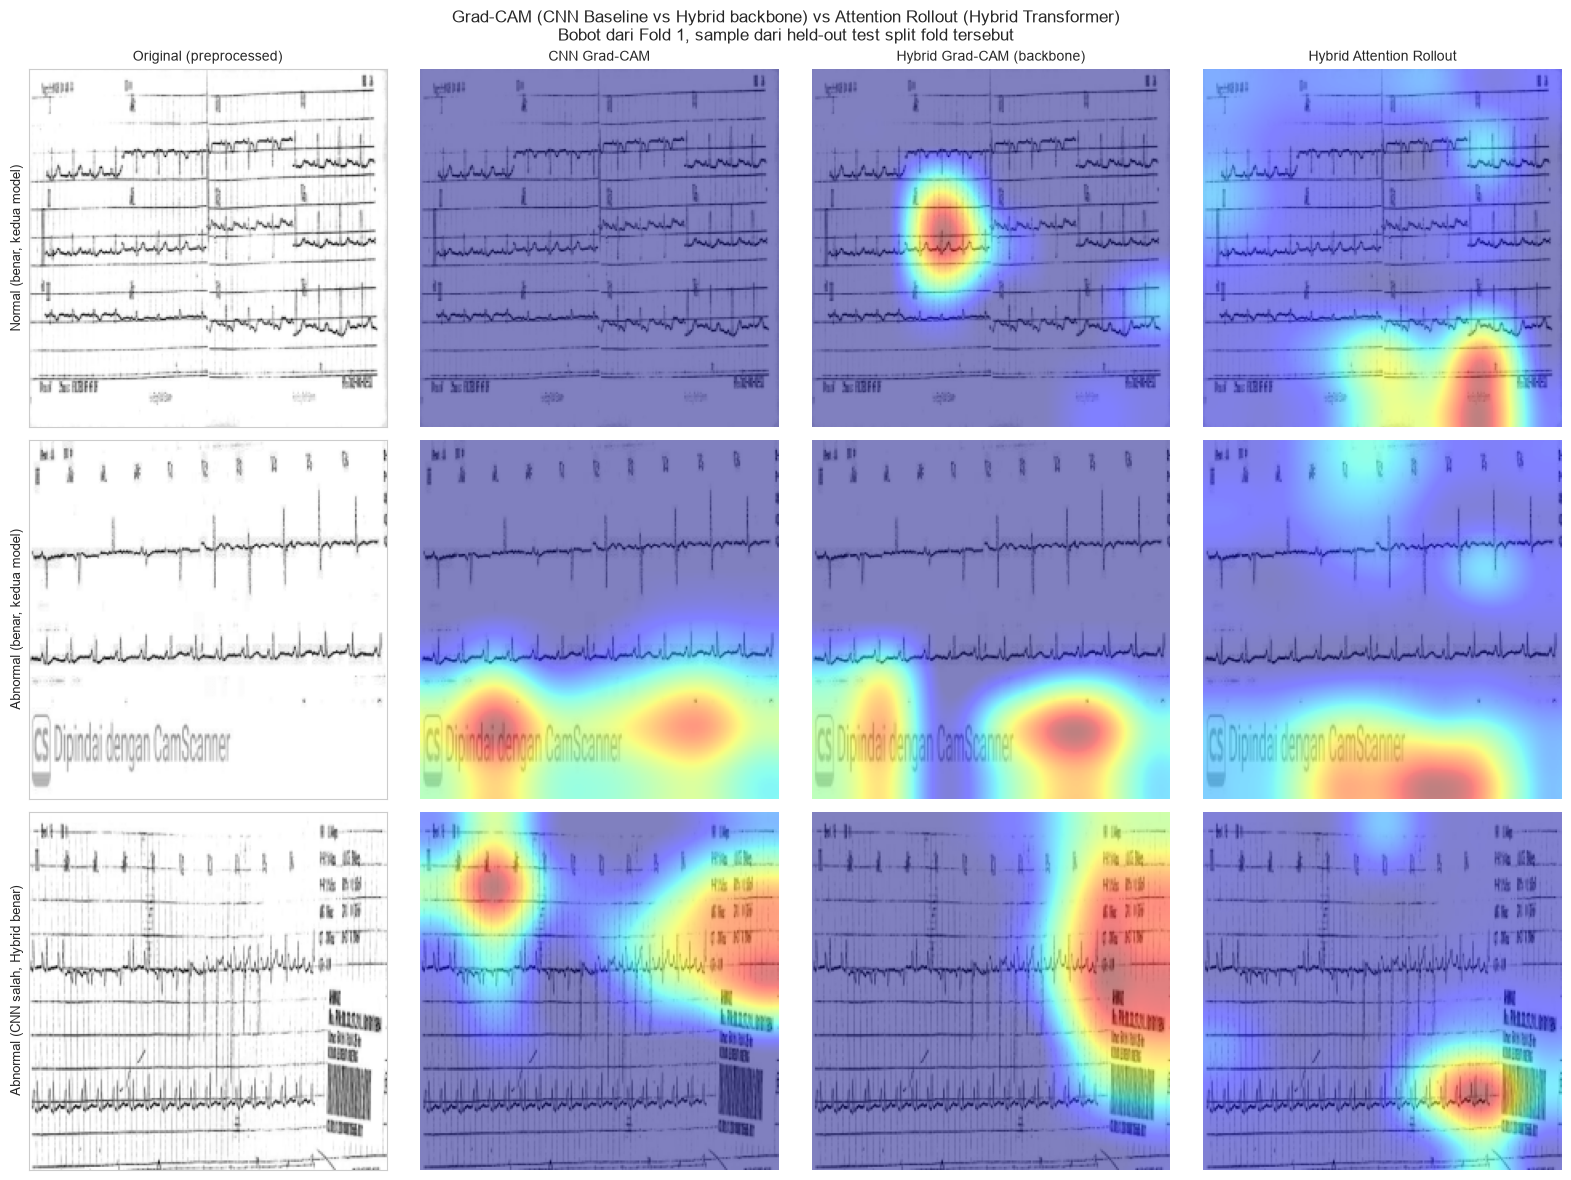

In [37]:
# --- 15.6 Figure: Original | CNN Grad-CAM | Hybrid Grad-CAM | Hybrid Attention Rollout ---
n_samples = len(explain_results)
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
if n_samples == 1:
    axes = axes[np.newaxis, :]

col_titles = ["Original (preprocessed)", "CNN Grad-CAM", "Hybrid Grad-CAM (backbone)", "Hybrid Attention Rollout"]

for row, res in enumerate(explain_results):
    orig = res["original"]
    axes[row, 0].imshow(orig, cmap="gray")
    axes[row, 0].set_ylabel(res["desc"], fontsize=9)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    for col, key in [(1, "cam_cnn_up"), (2, "cam_hybrid_up"), (3, "attn_up")]:
        axes[row, col].imshow(orig, cmap="gray")
        axes[row, col].imshow(res[key], cmap="jet", alpha=0.5)
        axes[row, col].axis("off")

    if row == 0:
        for col, title in enumerate(col_titles):
            axes[row, col].set_title(title, fontsize=10)

plt.suptitle(
    "Grad-CAM (CNN Baseline vs Hybrid backbone) vs Attention Rollout (Hybrid Transformer)\n"
    f"Bobot dari Fold {EXPLAIN_FOLD + 1}, sample dari held-out test split fold tersebut",
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [38]:
# --- 15.7 Ringkasan kuantitatif: konsentrasi (entropy) & kesepakatan spasial ---
# Dihitung pada resolusi grid token ASLI (7x7 = 49 sel), bukan versi upsampled, supaya angka
# entropy tidak bias oleh smoothing interpolasi saat upsample ke 224x224.
# Guard eksplisit untuk peta degenerate (all-zero): ini terjadi ketika GradCAM.compute() jatuh ke
# fallback-nya sendiri (cam_max - cam_min <= 1e-8, gradien target class terlalu datar untuk
# dilokalisasi -- misal CNN pada sample yang diprediksi Normal dengan sangat percaya diri, sehingga
# gradien logit Abnormal nyaris nol di semua sel). Tanpa guard ini, entropy/effective_area akan
# menghasilkan angka yang keliru (entropy->0 seolah "sangat terpusat", padahal maknanya justru
# "tidak ada sinyal lokal yang bisa dideteksi"; effective_area bisa >1, di luar rentang [0,1] yang
# dijanjikan). Kasus degenerate dilaporkan sebagai NaN (undefined), bukan angka yang menyesatkan.

DEGENERATE_SUM_THRESHOLD = 1e-6


def normalized_entropy(map_1d: np.ndarray, eps: float = 1e-12) -> float:
    """0 = sangat terpusat/lokal (mass menumpuk di sedikit sel), 1 = sangat menyebar/global
    (mass merata di semua 49 sel). NaN jika peta degenerate (all-zero / tidak ada sinyal)."""
    if map_1d.sum() < DEGENERATE_SUM_THRESHOLD:
        return float("nan")
    p = map_1d / map_1d.sum()
    p = np.clip(p, eps, None)
    ent = -np.sum(p * np.log(p))
    return float(ent / np.log(len(p)))


def effective_area(map_1d: np.ndarray, mass_frac: float = 0.8) -> float:
    """Fraksi dari 49 sel yang dibutuhkan untuk mencakup `mass_frac` dari total bobot peta.
    NaN jika peta degenerate (all-zero / tidak ada sinyal)."""
    if map_1d.sum() < DEGENERATE_SUM_THRESHOLD:
        return float("nan")
    p = map_1d / map_1d.sum()
    p_sorted = np.sort(p)[::-1]
    cum = np.cumsum(p_sorted)
    n_cells = int(np.searchsorted(cum, mass_frac) + 1)
    return min(n_cells, len(p)) / len(p)


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a_n = a / (np.linalg.norm(a) + 1e-12)
    b_n = b / (np.linalg.norm(b) + 1e-12)
    return float(np.dot(a_n, b_n))


explain_quant_rows = []
for res in explain_results:
    cam_cnn_flat = res["cam_cnn_grid"].flatten()
    cam_hybrid_flat = res["cam_hybrid_grid"].flatten()
    attn_flat = res["attn_grid"].flatten()

    explain_quant_rows.append({
        "sample": res["desc"],
        "entropy_cnn_gradcam": normalized_entropy(cam_cnn_flat),
        "entropy_hybrid_gradcam": normalized_entropy(cam_hybrid_flat),
        "entropy_hybrid_attention": normalized_entropy(attn_flat),
        "eff_area_cnn_gradcam": effective_area(cam_cnn_flat),
        "eff_area_hybrid_gradcam": effective_area(cam_hybrid_flat),
        "eff_area_hybrid_attention": effective_area(attn_flat),
        "cosine_hybrid_gradcam_vs_attention": cosine_similarity(cam_hybrid_flat, attn_flat),
    })

explain_quant_df = pd.DataFrame(explain_quant_rows)
n_degenerate_cnn = explain_quant_df["entropy_cnn_gradcam"].isna().sum()
print("=== Ringkasan Kuantitatif: Konsentrasi (entropy/effective-area) & Kesepakatan Spasial ===")
print("(entropy & effective_area: 0 = sangat terpusat/lokal, 1 = sangat menyebar/global; dihitung pada grid 7x7)")
if n_degenerate_cnn:
    print(f"CATATAN: {n_degenerate_cnn} peta CNN Grad-CAM degenerate (tanpa sinyal gradien yang bisa")
    print("dilokalisasi untuk target kelas Abnormal) -> dilaporkan sebagai NaN, bukan angka semu.")
explain_quant_df.round(3)

=== Ringkasan Kuantitatif: Konsentrasi (entropy/effective-area) & Kesepakatan Spasial ===
(entropy & effective_area: 0 = sangat terpusat/lokal, 1 = sangat menyebar/global; dihitung pada grid 7x7)
CATATAN: 1 peta CNN Grad-CAM degenerate (tanpa sinyal gradien yang bisa
dilokalisasi untuk target kelas Abnormal) -> dilaporkan sebagai NaN, bukan angka semu.


,sample,entropy_cnn_gradcam,entropy_hybrid_gradcam,entropy_hybrid_attention,eff_area_cnn_gradcam,eff_area_hybrid_gradcam,eff_area_hybrid_attention,cosine_hybrid_gradcam_vs_attention
0,"Normal (benar, kedua model)",NaN,0.501,0.963,NaN,0.102,0.673,0.217
1,"Abnormal (benar, kedua model)",0.786,0.712,0.954,0.306,0.224,0.612,0.705
2,"Abnormal (CNN salah, Hybrid benar)",0.785,0.703,0.892,0.286,0.224,0.571,0.397


In [39]:
# --- 15.8 Interpretasi otomatis berdasarkan hasil aktual di atas (bukan teks statis) ---
mean_ent_cnn = explain_quant_df["entropy_cnn_gradcam"].mean()
mean_ent_hybrid_cam = explain_quant_df["entropy_hybrid_gradcam"].mean()
mean_ent_attn = explain_quant_df["entropy_hybrid_attention"].mean()
mean_area_cnn = explain_quant_df["eff_area_cnn_gradcam"].mean()
mean_area_hybrid_cam = explain_quant_df["eff_area_hybrid_gradcam"].mean()
mean_area_attn = explain_quant_df["eff_area_hybrid_attention"].mean()
mean_cos = explain_quant_df["cosine_hybrid_gradcam_vs_attention"].mean()
n_valid_cnn = explain_quant_df["entropy_cnn_gradcam"].notna().sum()
n_total = len(explain_quant_df)

more_spread = "Attention Rollout" if mean_ent_attn > mean_ent_hybrid_cam else "Hybrid Grad-CAM"

print("=" * 72)
print("INTERPRETASI: LOKAL (Grad-CAM) vs GLOBAL (Attention Rollout)")
print("=" * 72)
print(f"\nRata-rata normalized entropy (n={n_total} sample, grid 7x7):")
cnn_note = "" if n_valid_cnn == n_total else f"  [dihitung dari {n_valid_cnn}/{n_total} sample valid, sisanya degenerate]"
print(f"  CNN Grad-CAM              : {mean_ent_cnn:.3f}  (effective area: {mean_area_cnn:.3f}){cnn_note}")
print(f"  Hybrid Grad-CAM (backbone): {mean_ent_hybrid_cam:.3f}  (effective area: {mean_area_hybrid_cam:.3f})")
print(f"  Hybrid Attention Rollout  : {mean_ent_attn:.3f}  (effective area: {mean_area_attn:.3f})")
print(f"\n-> Peta yang lebih menyebar (entropy lebih tinggi): {more_spread}")

print(f"\nRata-rata cosine similarity Hybrid Grad-CAM vs Attention Rollout: {mean_cos:.3f}")
if mean_cos < 0.5:
    print("   Kesepakatan RENDAH -> attention menyorot wilayah yang cukup BERBEDA dari wilayah lokal")
    print("   yang memicu Grad-CAM. Ini mendukung klaim bahwa Transformer menambahkan konteks GLOBAL")
    print("   di luar evidence lokal backbone -- bukan sekadar menegaskan ulang temuan CNN.")
else:
    print("   Kesepakatan CUKUP TINGGI -> attention masih banyak berfokus di wilayah lokal yang sama")
    print("   dengan Grad-CAM. Pada sample ini, kontribusi Transformer lebih ke penguatan evidence")
    print("   lokal ketimbang menemukan hubungan spasial baru yang jauh dari wilayah tersebut.")

if n_valid_cnn < n_total:
    print(f"\nCatatan tambahan: {n_total - n_valid_cnn} dari {n_total} peta CNN Grad-CAM degenerate")
    print("(gradien target kelas Abnormal nyaris nol di semua sel -- biasanya terjadi saat CNN")
    print("memprediksi Normal dengan sangat percaya diri, sehingga tidak ada wilayah yang bisa")
    print("dilokalisasi sebagai 'bukti Abnormal'). Ini BUKAN kegagalan Grad-CAM, melainkan sinyal")
    print("bahwa evidence CNN untuk kelas Abnormal memang tidak terlokalisasi pada sample tersebut.")

print(f"""
Catatan: hasil di atas berbasis bobot Fold {EXPLAIN_FOLD + 1} (ilustratif, satu fold, bukan
ensemble 5-fold), dan berbasis {n_total} sample yang dipilih dari held-out test
split fold tersebut. Ini BUKAN klaim statistik yang kuat (n kecil, tidak diuji signifikansi),
melainkan bukti pendukung (supporting evidence) untuk framing "CNN = evidence lokal, Transformer
= relasi global" yang mendasari desain arsitektur Hybrid: backbone ResNet18 (layer4 fine-tuned)
mengekstrak pola tekstur/morfologi pada reseptor lokal 7x7 token, lalu TransformerEncoder
menghubungkan token-token tersebut lintas seluruh citra lewat self-attention sebelum
diklasifikasikan dari token [CLS].
""")

INTERPRETASI: LOKAL (Grad-CAM) vs GLOBAL (Attention Rollout)

Rata-rata normalized entropy (n=3 sample, grid 7x7):
  CNN Grad-CAM              : 0.785  (effective area: 0.296)  [dihitung dari 2/3 sample valid, sisanya degenerate]
  Hybrid Grad-CAM (backbone): 0.638  (effective area: 0.184)
  Hybrid Attention Rollout  : 0.937  (effective area: 0.619)

-> Peta yang lebih menyebar (entropy lebih tinggi): Attention Rollout

Rata-rata cosine similarity Hybrid Grad-CAM vs Attention Rollout: 0.440
   Kesepakatan RENDAH -> attention menyorot wilayah yang cukup BERBEDA dari wilayah lokal
   yang memicu Grad-CAM. Ini mendukung klaim bahwa Transformer menambahkan konteks GLOBAL
   di luar evidence lokal backbone -- bukan sekadar menegaskan ulang temuan CNN.

Catatan tambahan: 1 dari 3 peta CNN Grad-CAM degenerate
(gradien target kelas Abnormal nyaris nol di semua sel -- biasanya terjadi saat CNN
memprediksi Normal dengan sangat percaya diri, sehingga tidak ada wilayah yang bisa
dilokalisasi sebag